# $\mathbb{Z}_{2}$-symmetric singlet extension of the Standard Model (Z2SSM)

In [1]:
import pandas as pd
import numpy as np
import os, sys
import subprocess

import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rc("axes",labelsize="large")

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['text.usetex'] = False

from scipy import interpolate
import scipy.stats 
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

os.chdir('/cephfs/user/mrebuzzi/phd/HiggsTools/future_projections/')
# os.getcwd()

In [2]:
sys.path.append(os.path.abspath("./code"))

import utils

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport utils
%aimport utils.plotting_utils
%aimport utils.common_utils

In [3]:
from utils.common_utils import M_PI, GF, mHl, vev, Mh
sqrt = np.sqrt

# from pyCollier import db0
# print(f"Testing db0 function from pyCollier: {db0(Mh**2, Mh**2, Mh**2)}")

In [4]:
dZh_Johannes = -(Mh**2*(-9 + 2*np.sqrt(3)*np.pi))/(32*np.pi**2*vev**2)
dZH_Hepfit = -(9.0/16.0)*( GF*mHl*mHl/sqrt(2.0)/M_PI/M_PI )*( 2.0*M_PI/3.0/sqrt(3.0) - 1.0 )
print(f"\nJohannes' dZh: {dZh_Johannes}")
print(f"HEPfit's dZh: {dZH_Hepfit}")


Johannes' dZh: -0.0015389438916101252
HEPfit's dZh: -0.0015389438816829494


#### Comparing C1 coefficients

In [5]:
from utils.common_utils import smeft_sigma_Zh, smeft_sigma_Zh_general_C1, effZZh1Lkala_HEPfit_C1_values, ZZh_hextleg
from utils.common_utils import C1_hepfit, C1_decay_rates

from pyCollier import b0, c0
B0 = b0
C0 = c0

MZ=91.187
# Mh=125.1

@np.vectorize
def dkappaZkala(S,kappalam):
    prediags = 3/2 - (3*(2*Mh**4 + (MZ**2 - S)**2 - Mh**2*(3*MZ**2 + S))*B0(Mh**2,Mh**2,Mh**2))/(2.*(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))) + (3*Mh**2*(Mh**2 - MZ**2 - S)*B0(MZ**2,Mh**2,MZ**2))/(2.*(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))) + (3*(Mh**4 - 2*Mh**2*MZ**2 + (MZ**2 - S)**2)*B0(S,Mh**2,MZ**2))/(2.*(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))) - 6*MZ**2*C0(Mh**2,MZ**2,S,Mh**2,Mh**2,MZ**2) + (3*Mh**2*(Mh**4 + (MZ**2 - S)**2 - Mh**2*(2*MZ**2 + S))*C0(S,Mh**2,MZ**2,MZ**2,Mh**2,Mh**2))/(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))
    return np.real((kappalam-1)*Mh**2/(16*np.pi**2*vev**2)*prediags)

c1_johannes = {
    240: 2*dkappaZkala(240**2, 2.0),
    365: 2*dkappaZkala(365**2, 2.0),
    500: 2*dkappaZkala(500**2, 2.0),
}

kappalam = 2.0
for sqrt_S in [240, 365, 500]:
    S = sqrt_S**2
    print(f"C1_johannes = dkappaZkala({sqrt(S)}**2, {kappalam}) = {c1_johannes[sqrt_S]}")
    print(f"C1_hepfit = {C1_hepfit[sqrt_S]}\n")

# BPB_6 comparison:
kappalam = 4.332584967850238
effZZh1Lkala_johannes = {
    240: 0.0305539283144288,
    365: 0.0108939113198954, 
    500: 0.0027204987465047,
}
for sqrt_S in [240, 365, 500]:
    S = sqrt_S**2
    effZZh1Lkala_formula = dkappaZkala(S,kappalam)
    print(f"2*effZZh1Lkala_datacolumn = {2*effZZh1Lkala_johannes[sqrt_S]}")
    print(f"2*effZZh1Lkala_formula = dkappaZkala({sqrt(S)}**2, {kappalam}) = {2*effZZh1Lkala_formula}")
    print(f"HEPfit expression = C1*(kappalam - 1) = {C1_hepfit[sqrt_S]*(kappalam-1)}\n")


@np.vectorize
def smeft_sigma_Zh_Johannes_C1_values(lmbd, sqrt_s):
    return smeft_sigma_Zh_general_C1(lmbd, sqrt_s, C1_values=c1_johannes)

print(f"{effZZh1Lkala_HEPfit_C1_values(2.0, 240)}")

C1_johannes = dkappaZkala(240.0**2, 2.0) = 0.01833647370385779
C1_hepfit = 0.017

C1_johannes = dkappaZkala(365.0**2, 2.0) = 0.0065378145943704455
C1_hepfit = 0.0057

C1_johannes = dkappaZkala(500.0**2, 2.0) = 0.001632665797121269
C1_hepfit = 0.00099

2*effZZh1Lkala_datacolumn = 0.0611078566288576
2*effZZh1Lkala_formula = dkappaZkala(240.0**2, 4.332584967850238) = 0.06110785662885765
HEPfit expression = C1*(kappalam - 1) = 0.05665394445345405

2*effZZh1Lkala_datacolumn = 0.0217878226397908
2*effZZh1Lkala_formula = dkappaZkala(365.0**2, 4.332584967850238) = 0.021787822639790847
HEPfit expression = C1*(kappalam - 1) = 0.01899573431674636

2*effZZh1Lkala_datacolumn = 0.0054409974930094
2*effZZh1Lkala_formula = dkappaZkala(500.0**2, 4.332584967850238) = 0.0054409974930095676
HEPfit expression = C1*(kappalam - 1) = 0.0032992591181717356

0.017


In [9]:
def read_Z2SSM_file(
    df, 
    loop_order=2,
    max_num_bulk_points=None,
    data_with_WFR=False, 
    data_with_WFR_no_BSM=False,
    data_with_WFR_HEPfit_C1_values=False,
):

    # Check that at most one of the excluse flags were set to True
    exclusive_flag_count = sum([
        data_with_WFR, 
        data_with_WFR_no_BSM, 
        data_with_WFR_HEPfit_C1_values
    ])
    if exclusive_flag_count > 1:
        raise ValueError("""At most one of the following flags can be used:
            data_with_WFR,
            data_with_WFR_no_BSM,
            data_with_WFR_HEPfit_C1_values
        """)
    
    if max_num_bulk_points is not None:
        df = df[:max_num_bulk_points]

    kappas = {}
    EWPOs = {}
    model_pars = {}

    if loop_order==1:
        kappas["lam"] = df['kappaLam1L']
        kappas['kappaSingleHiggs'] = df['kappaSingleHiggs1L']
    
    elif loop_order==2:
        kappas["lam"] = df['kappaLam2L']
        kappas['kappaSingleHiggs'] = df['kappaSingleHiggs2L']

    else:
        raise ValueError("Wrong loop order argument!")

    kappas["lam1L"] = df['kappaLam1L']

    # No EWPO predictions for Z2SSM yet !!
    # EWPOs['Mw'] = df['MW2L']
    # EWPOs['sin2thetaEff'] = df['sl2L']
    # EWPOs['GammaZ'] = df['GamZ2L']


    klam = np.array(kappas['lam'], dtype=complex).real

    for fermion in ['uu', 'dd', 'ss', 'cc', 'bb', 'tt', 'ee', 'mumu', 'tautau']:
        kappas[fermion] = kappas['kappaSingleHiggs']

    kappas['ZZ']     = kappas['kappaSingleHiggs']
    kappas['WW']     = kappas['kappaSingleHiggs']
    kappas['gamgam'] = kappas['kappaSingleHiggs']
    kappas['Zgam']   = kappas['kappaSingleHiggs']
    kappas['gg']     = kappas['kappaSingleHiggs']

    for s in ['0', '240', '365', '500', '550']:
        # Standard prediction
        kappas[f'ZZ_{s}'] = sqrt(
            2 * (kappas['kappaSingleHiggs'].to_numpy() - 1)
            + 2 * df[f'effZZh2Lkala_s{s}'].to_numpy()
            + 1
        )
        # With WFR. Also corresponds to the 'smeft_formula_Johannes_C1_values' flag 
        # for the IDM
        kappas[f'ZZ_{s}_with_WFR'] = sqrt(
            2 * (kappas['kappaSingleHiggs'].to_numpy() - 1)
            + 2 * df[f'effZZh2Lkala_s{s}'].to_numpy()
            + ZZh_hextleg(klam)
            + 1
        )
        # No corrections for BSM particles directly, no WFR
        kappas[f'ZZ_{s}_no_BSM'] = sqrt(
            2 * df[f'effZZh2Lkala_s{s}'].to_numpy()
            + 1
        )
        # With WFR, no corrections for BSM particles directly
        kappas[f'ZZ_{s}_with_WFR_no_BSM'] = sqrt(
            2 * df[f'effZZh2Lkala_s{s}'].to_numpy()
            + ZZh_hextleg(klam)
            + 1
        )
        
        if s in ['240', '365', '500']:
            # Using HEPfit C1 values, without the Higgs WFR
            kappas[f'ZZ_{s}_use_HEPfit_C1_values'] = sqrt(
                2 * (kappas['kappaSingleHiggs'].to_numpy() - 1)
                + effZZh1Lkala_HEPfit_C1_values(klam, int(s))
                + 1
            )
            # With WFR, using HEPfit C1 values. Also corresponds to the 'smeft_formula'
            # flag for the IDM
            kappas[f'ZZ_{s}_with_WFR_HEPfit_C1_values'] = sqrt(
                2 * (kappas['kappaSingleHiggs'].to_numpy() - 1)
                + effZZh1Lkala_HEPfit_C1_values(klam, int(s))
                + ZZh_hextleg(klam)
                + 1
            )

        if data_with_WFR: 
            kappas[f'ZZ_{s}'] = kappas[f'ZZ_{s}_with_WFR']
        elif data_with_WFR_no_BSM:
            kappas[f'ZZ_{s}'] = kappas[f'ZZ_{s}_with_WFR_no_BSM']
        elif data_with_WFR_HEPfit_C1_values and s in ['240', '365', '500']:
            kappas[f'ZZ_{s}'] = kappas[f'ZZ_{s}_with_WFR_HEPfit_C1_values']

    # Implement terms proportional to (klam-1) into the ZZ, WW, gg and gamgam Higgs couplings
    for coup in ['ZZ', 'WW', 'gg', 'gamgam']:
        kappas[f"{coup}_HEPfit_C1"] = sqrt(
            2 * (kappas['kappaSingleHiggs'].to_numpy() - 1)
            + C1_decay_rates[coup] * (klam - 1)
            + 1
        )

    for par in ["mS", "muS", "lamS", "lamSH"]:
        model_pars[par] = df[par]

    return kappas, EWPOs, model_pars

### Plot EffZZH[240] vs EffZZH[365]

In [7]:
from utils.plotting_utils import plot_EffZZH_240_vs_365, plot_self_consistent_curve, plot_curves
upper_right_text="FCC-ee Projections"
model_name = r"$\mathbb{Z}_{2}$-symmetric SSM"
plot_dir = "plots/Z2SSM"
data_file = "data/Z2SSM/Z2SSM_scan_combined"
# data_file = "data/Z2SSM/Z2SSM_scan_combined_mod"
# data_file = "data/Z2SSM/Z2_SSM_scan_energy_dependence"
max_num_bulk_points = None
# max_num_bulk_points = 20_000

Processing data file: data/Z2SSM/Z2SSM_scan_combined


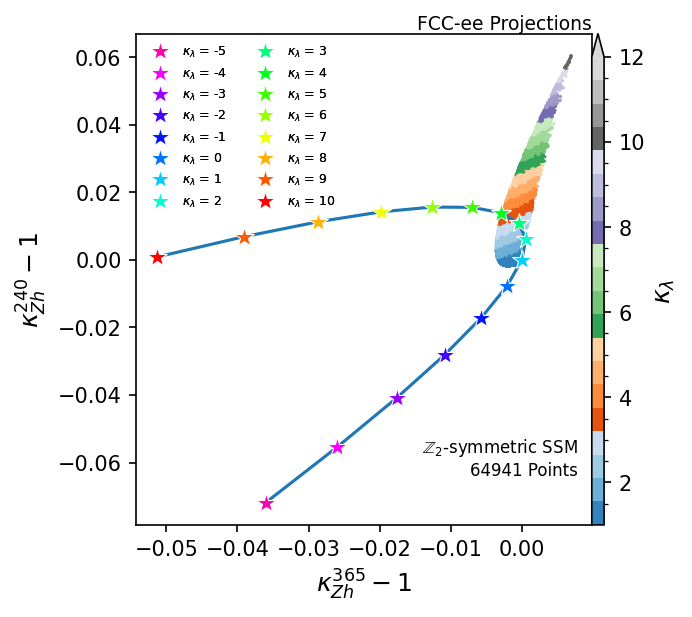

In [9]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        plot_self_consistent_curve='CH',
                        model_name=model_name, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                )

Processing data file: data/Z2SSM/Z2SSM_scan_combined


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

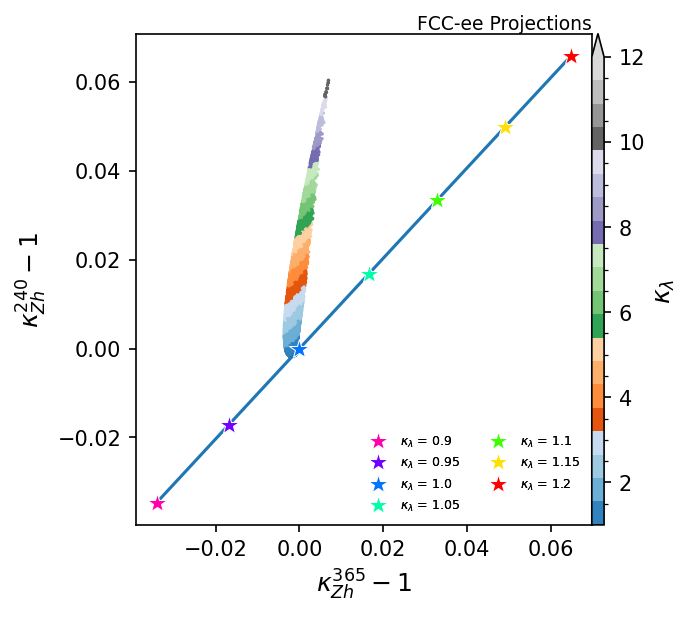

In [10]:
plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        plot_self_consistent_curve='CHbox',
                        model_name=model_name, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        no_model_text=True,
                )

Processing data file: data/Z2SSM/Z2SSM_scan_combined


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

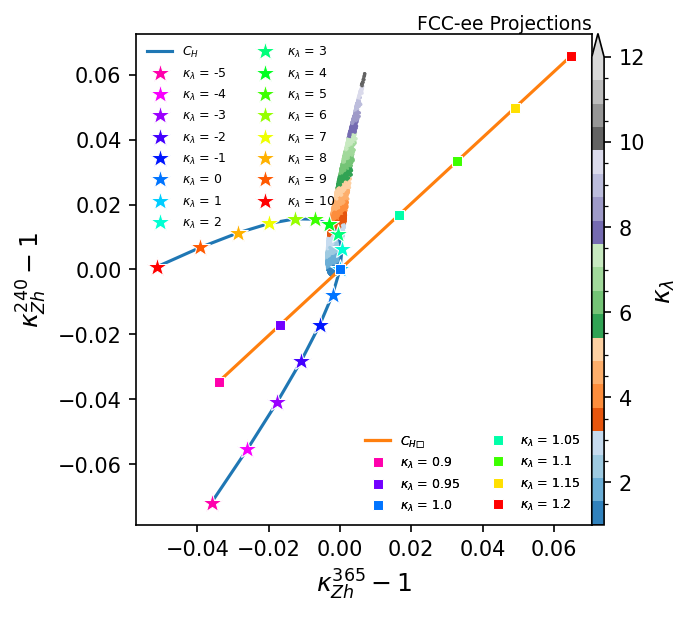

In [11]:
plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        plot_self_consistent_curve=['CH', 'CHbox'],
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                )

Processing data file: data/Z2SSM/Z2SSM_scan_combined


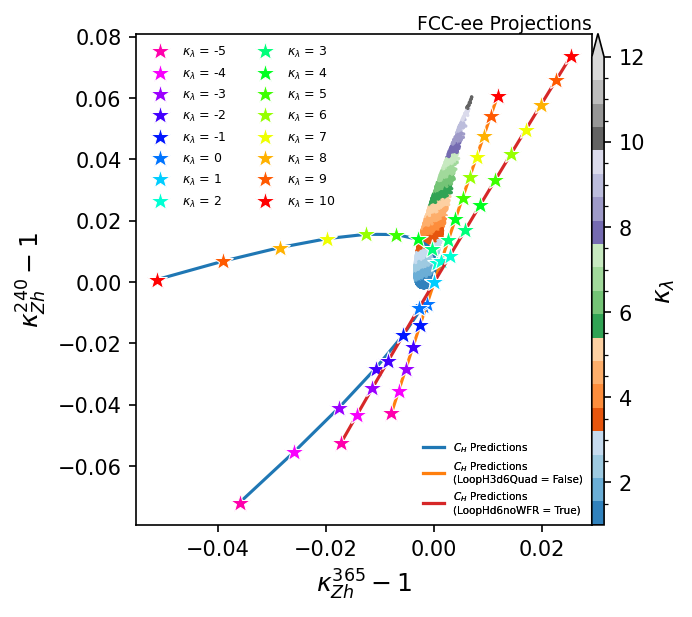

In [12]:
plot_name = "Z2SSM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves"
fig, ax = plot_EffZZH_240_vs_365(
    data_file, read_Z2SSM_file, no_model_text=True, upper_right_text=upper_right_text, max_num_bulk_points=max_num_bulk_points,
)

file_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee"
files = [
    f"{file_dir}/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions.txt",
    f"{file_dir}/large_kappa_lambda_fits_noLoopH3d6Quad/comparison_plots/k_ZH_240_365_predictions.txt",
    # f"{file_dir}/large_kappa_lambda_fits_noSubleading/comparison_plots/k_ZH_240_365_predictions.txt",
    f"{file_dir}/large_kappa_lambda_fits_LoopHd6noWFR/comparison_plots/k_ZH_240_365_predictions.txt",
]
labels = [
    # r'$C_{H}$ Predictions'+' \n(LoopH3d6Quad = True)',
    r'$C_{H}$ Predictions'+'',
    r'$C_{H}$ Predictions'+' \n(LoopH3d6Quad = False)',
    # r'$C_{H}$ Predictions'+' \n(LoopHd6NoSubleading = True)',
    r'$C_{H}$ Predictions'+' \n(LoopHd6noWFR = True)',
    # r'$C_{H\u25A1}$',
]
curves = ["CH" for _ in range(len(files))]
markers = ["*" for _ in range(len(files))]
markersizes = [10 for _ in range(len(files))]
colors = ["tab:blue", "tab:orange", "tab:red",]

fig, ax = plot_self_consistent_curve(
    curves, 
    files, 
    fig, 
    ax, 
    labels, 
    colors, 
    markers, 
    markersizes, 
    n_legends=1
)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

Processing data file: data/Z2SSM/Z2SSM_scan_combined
Number of points satisfying the 5% SM constraint on the single higgs couplings: 64941 / 64941


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

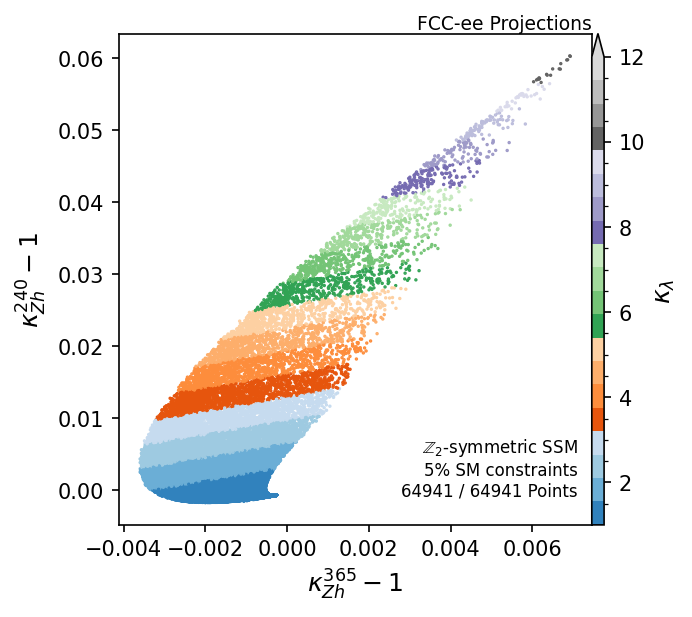

In [13]:
BR_constraints = 0.05
plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints, max_num_bulk_points=max_num_bulk_points,
                )

Processing data file: data/Z2SSM/Z2SSM_scan_combined
Number of points satisfying the 5% SM constraint on the single higgs couplings: 64941 / 64941


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

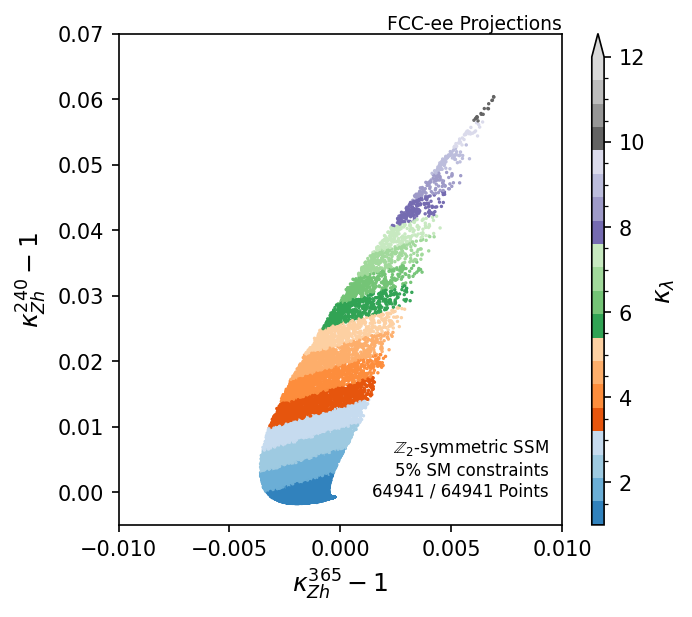

In [14]:
BR_constraints = 0.05
plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints, max_num_bulk_points=max_num_bulk_points,
                       zoom=True,
                       zoom_range_x=(-0.01, 0.01),
                       zoom_range_y=(-0.005, 0.07),
                )

Processing data file: data/Z2SSM/Z2SSM_scan_combined
Number of points satisfying the 1% SM constraint on the single higgs couplings: 60017 / 64941


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

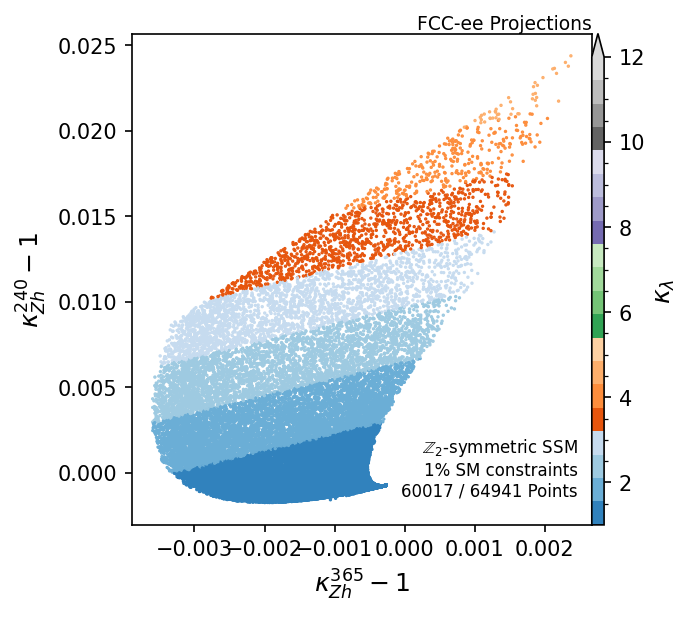

In [15]:
BR_constraints = 0.01
plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints, max_num_bulk_points=max_num_bulk_points,
                )

### Finding Outlier Points 

In [10]:
from utils.common_utils import find_benchmark

# data_file = "data/Z2SSM/Z2SSM_scan_combined"

BR_constraints=0.05
df = pd.read_csv(data_file + ".csv")

df = df.replace("", np.nan)
df = df.dropna()
old_df_indices = df.index.to_numpy()
df = df.reset_index(drop=True)

kappas, EWPOs, model_pars = read_Z2SSM_file(df)
n_pts = df.shape[0]

output_dir = "./scan_output/Z2SSM_scan_output"
subprocess.run(["mkdir", "-p", output_dir])

BP_filename = f"{output_dir}/Benchmark_Points_outliers_fixed.txt"
with open(BP_filename, "w") as BP_output_file:

    max_errors_365 = [2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 4e-4, 2e-4, 2e-4, 3e-4, 4e-4, 4e-4, 4e-4,]
    max_errors_240 = [1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 2e-3, 2e-3, 1e-3, 2e-3, 2e-3, 3e-3, 2e-3,]
    delta_kappas_z_365 = [-0.002, -0.0037, -0.0032, -0.0001, -0.0015, 0.0011, -0.000, 0.0030, 0.0016, 0.0042, 0.0036, 0.0062, 0.0053, 0.0073]
    delta_kappas_z_240 = [-0.0025, 0.0035,   0.0122, -0.0015,  0.023,  0.011,  0.030,  0.0245, 0.0395, 0.0390, 0.0490, 0.052,  0.057,  0.062]

    BP_Names = []
    BP_Names = BP_Names + [f"BPBnew_{i}" for i in range(len(delta_kappas_z_240))]
    BP_Names_legend = []
    BP_Names_legend = BP_Names_legend + [f"New BPB {i}" for i in range(len(delta_kappas_z_240))]

    bp_kappas , bp_EWPOs, bp_model_pars, bp_indices = find_benchmark(n_pts=n_pts,
                               kappas=kappas,
                               EWPOs=EWPOs,
                               model_pars=model_pars,
                               old_df_indices=old_df_indices,
                               BP_Names=BP_Names,
                               BP_output_file=BP_output_file,
                               max_errors_365=max_errors_365,
                               max_errors_240=max_errors_240,
                               delta_kappas_z_365=delta_kappas_z_365,
                               delta_kappas_z_240=delta_kappas_z_240,
                               BR_constraints=BR_constraints,
                              )

import pickle
BP_dicts_filename = f"{output_dir}/Benchmark_Points_outliers_dicts.pkl"
with open(BP_dicts_filename, 'wb') as f:
    pickle.dump({
        "kappas": bp_kappas,
        "EWPOs": bp_EWPOs,
        "model_pars": bp_model_pars,
        "indices": bp_indices
    }, f)


elif BP == "BPBnew_0":
    kappas['lam'] = 1.0643594459030925
    kappas['kappaSingleHiggs'] = 0.997795157109014
    kappas['lam1L'] = 1.0163047292403735
    kappas['uu'] = 0.997795157109014
    kappas['dd'] = 0.997795157109014
    kappas['ss'] = 0.997795157109014
    kappas['cc'] = 0.997795157109014
    kappas['bb'] = 0.997795157109014
    kappas['tt'] = 0.997795157109014
    kappas['ee'] = 0.997795157109014
    kappas['mumu'] = 0.997795157109014
    kappas['tautau'] = 0.997795157109014
    kappas['ZZ'] = 0.997795157109014
    kappas['WW'] = 0.997795157109014
    kappas['gamgam'] = 0.997795157109014
    kappas['Zgam'] = 0.997795157109014
    kappas['gg'] = 0.997795157109014
    kappas['ZZ_0'] = 0.9980563471636651
    kappas['ZZ_0_with_WFR'] = 0.9979539099793131
    kappas['ZZ_0_no_BSM'] = 1.0002630443516598
    kappas['ZZ_0_with_WFR_no_BSM'] = 1.0001608331788296
    kappas['ZZ_240'] = 0.9983849781927755
    kappas['ZZ_240_with_WFR'] = 0.9982825747303763
    kappas['ZZ_240_no_BSM'] = 

In [10]:
print("std::vector<float> base_KappaLambdas = {")
for BP, BP_name in zip(bp_kappas, BP_Names):
    print(f"        {BP['lam']}, // {BP_name}")
print("    };")

std::vector<float> base_KappaLambdas = {
        1.0643594459030925, // BPBnew_0
        2.068362744578383, // BPBnew_1
        3.41660475844658, // BPBnew_2
        0.9197317035823376, // BPBnew_3
        4.996504503173265, // BPBnew_4
        2.723103795696014, // BPBnew_5
        6.114019817191308, // BPBnew_6
        4.878015572616551, // BPBnew_7
        7.24831645311373, // BPBnew_8
        7.005268951781772, // BPBnew_9
        8.535635929341407, // BPBnew_10
        8.84021000223677, // BPBnew_11
        9.584476423981522, // BPBnew_12
        10.34814810189343, // BPBnew_13
    };


### Plotting the obtained points

Processing data file: data/Z2SSM/Z2SSM_scan_combined
Number of points satisfying the 5% SM constraint on the single higgs couplings: 64941 / 64941


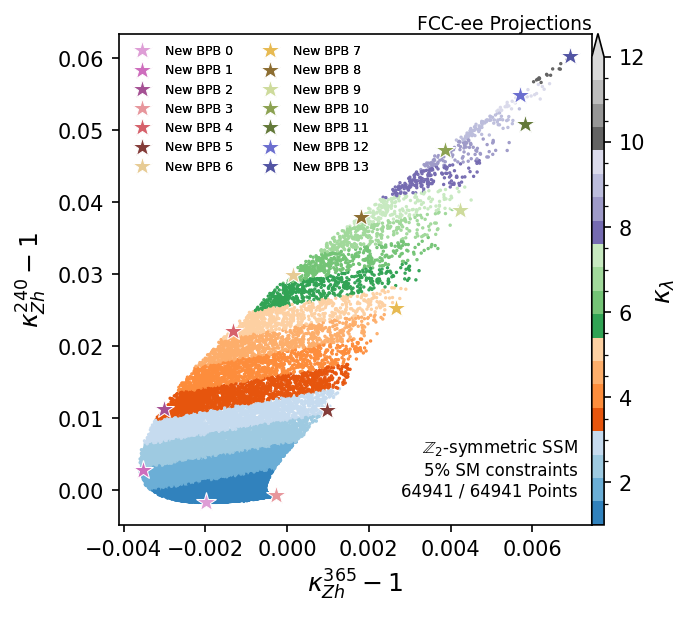

In [18]:
BR_constraints = 0.05
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas, BP_Names_legend)]
colors = mpl.colormaps['tab20b']
color = list(colors(np.linspace(0.001, 0.999, len(plot_points)+1)[::-1]))

plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints, max_num_bulk_points=max_num_bulk_points,
                       plot_points=plot_points,
                    #    point_colors=color
                )
plt.savefig(f'{plot_dir}/{plot_name}'+"_all_BPs.pdf")

## Plotting the obtained points including the Higgs self-energy contributions to $\sigma_{Zh}$

Processing data file: data/Z2SSM/Z2SSM_scan_combined


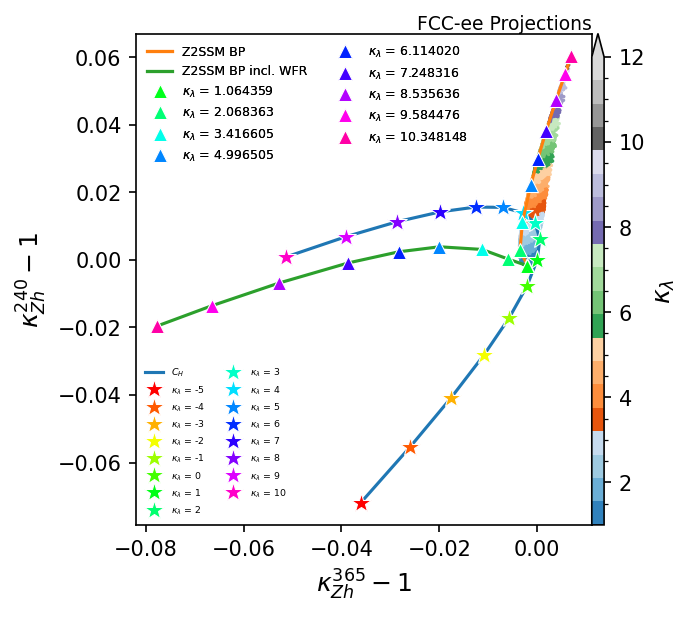

In [19]:
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas, BP_Names_legend)]

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]

# Plot only the even-numbered BPBs
BP_indices_for_curve = [0, 1, 2, 4, 6, 8, 10, 12, 13]
plot_points = [plot_points[i] for i in BP_indices_for_curve]
plot_points_with_WFR = [plot_points_with_WFR[i] for i in BP_indices_for_curve]

plot_name = "Z2SSM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_with_WFR"

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                )

curves = ["CH", "Z2SSM", "Z2SSM_SMEFT",]
file_names = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions.txt",
    # "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits_CHbox/comparison_plots/k_ZH_240_365_predictions.txt",
    None,
    None,
]
data_sets = [
    None,
    plot_points,
    plot_points_with_WFR,
]
legend_locs = ['lower left', None, 'upper left']
legend_fontsizes = [4.5, 6.0, 6.0]
legend_cols = [2, 2, 2]
markers = ['*', '^', '^']
color_lines = ["tab:blue", "tab:orange", "tab:green"]
label_lines = [r'$C_{H}$', r'Z2SSM BP', r'Z2SSM BP incl. WFR']
markersizes = [10, 7, 7]

plot_curves(ax, curves, file_names, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

Similar plot, but now instead of assuming integer values for $\kappa_\lambda$ for the points in the SMEFT curves, we take $\kappa_\lambda$ values corresponding to the Z2SSM BPs

Processing data file: data/Z2SSM/Z2SSM_scan_combined


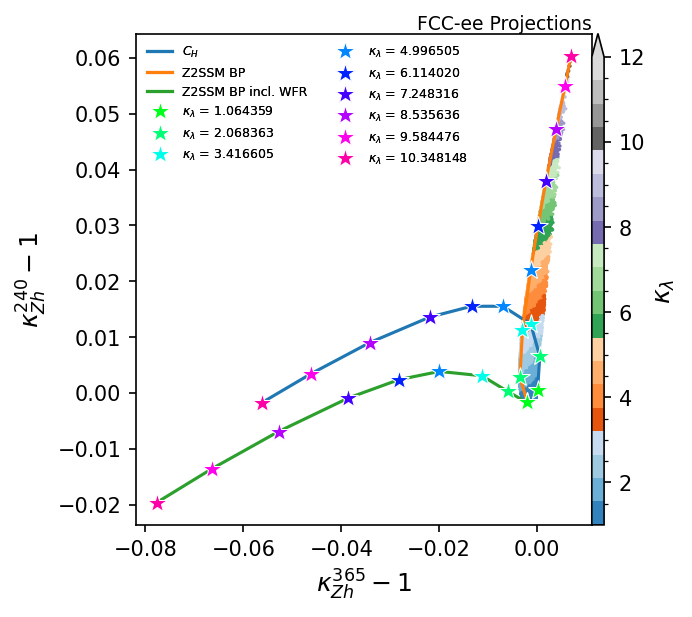

In [20]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                )

legend_locs = [None, None, 'upper left',]
legend_fontsizes = [6.0, 6.0, 6.0,]
markers = ["*", "*", "*", ]
markersizes = [10, 10, 10, ]
curves_matching_lambdas = [
    "CH_matching_lambdas", 
    # "CHbox", 
    "Z2SSM",
    "Z2SSM_SMEFT",
]
file_names_matching_lambdas = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions_general_lambdas_Z2SSM.txt",
    # "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits_CHbox/comparison_plots/k_ZH_240_365_predictions_general_lambdas_Z2SSM.txt",
    None,
    None,
]

plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas.pdf")

# Comparing Z2SSM and SMEFT

### Consistency check using interpolation in $C_H$ vs. $C_{H□}$ grid
The `generate_HEPfit_predictions` directory contains the setup and results for SMEFT predictions on a grid of points in the $C_H$ vs. $C_{H□}$ plane. Predictions for $\kappa_{Zh}^{240}$, $\kappa_{Zh}^{365}$, and $\kappa_\lambda$, for each point in the grid, are stored in the `input_file` read below. 

In [21]:
input_file = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/generate_HEPfit_predictions/results/k_ZH_240_365_central_value_results.txt"

k_ZH_240 = []
k_ZH_365 = []
lmbd = []
CH = []
CHBox = []

with open(input_file, "r") as f:
    for i, line in enumerate(f):
        if i == 0:
            continue  # skip header if there is one
        columns = line.strip().split(",")
        if len(columns) < 5:
            continue  # skip malformed lines
        k_ZH_240.append(float(columns[0]))
        k_ZH_365.append(float(columns[1]))
        lmbd.append(float(columns[2]))
        CH.append(float(columns[3]))
        CHBox.append(float(columns[4]))

print(len(CH))

from scipy.interpolate import LinearNDInterpolator
import numpy as np

interp = LinearNDInterpolator(list(zip(k_ZH_365, k_ZH_240)), lmbd)

1620


plot_points_interpolation = [(-0.00209851512017023, -0.001717425269623707, nan, 'New BPB 0'), (-0.006054717788453234, 0.0002775710382483254, -0.049287394385828964, 'New BPB 1'), (-0.01127757791009254, 0.003063396462631207, -0.1114269362160667, 'New BPB 2'), (-0.019965838518608003, 0.0038453288843005584, -0.18429276891820834, 'New BPB 4'), (-0.028247640701011045, 0.0023722414852438423, -0.23580057700232704, 'New BPB 6'), (-0.03860164146196832, -0.0009296336389417181, -0.28788618224589246, 'New BPB 8'), (-0.052820470809043285, -0.006913948064165565, -0.3471072155155941, 'New BPB 10'), (-0.06642105031830514, -0.013573244291584574, -0.3955429157428707, 'New BPB 12'), (-0.07771001937247424, -0.01963605782090394, -0.4306037773980318, 'New BPB 13')]
Processing data file: data/Z2SSM/Z2SSM_scan_combined


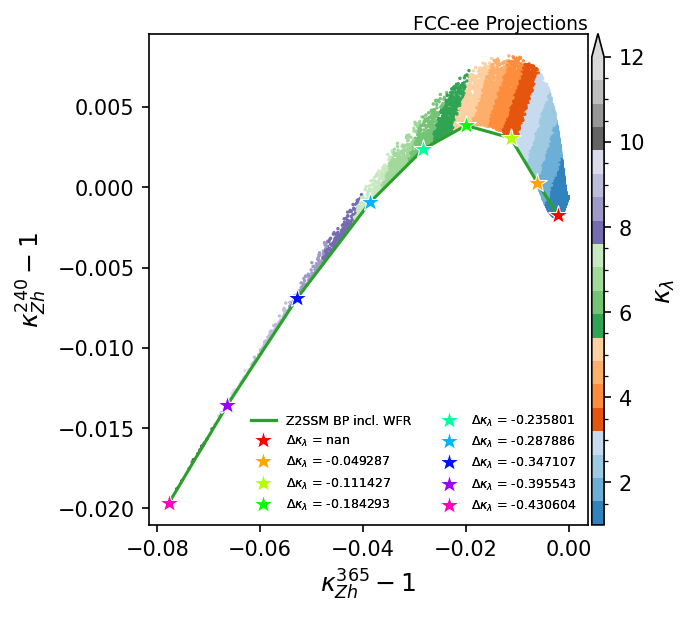

In [22]:
# x = np.array([sqrt( (BP["ZZ_365"])**2 + ZZh_hextleg( BP["lam"] ) ) - 1 for BP in bp_kappas])
x = np.array([BP["ZZ_365_with_WFR"] - 1 for BP in bp_kappas])
# y = np.array([sqrt( (BP["ZZ_240"])**2 + ZZh_hextleg( BP["lam"] ) ) - 1 for BP in bp_kappas])
y = np.array([BP["ZZ_240_with_WFR"] - 1 for BP in bp_kappas])
lmbd_BPs = np.array([BP["lam"] for BP in bp_kappas])

X, Y = np.meshgrid(np.array(x)+1, np.array(y)+1)  # 2D grid for interpolation
Z = interp(X, Y)
Z = np.array([Z[i,i] for i in range(Z.shape[0])])


plot_points_interpolation = tuple(zip(x, y, lmbd_BPs-Z, BP_Names_legend))
plot_points_interpolation = [plot_points_interpolation[i] for i in BP_indices_for_curve]
print(f"plot_points_interpolation = {plot_points_interpolation}")

plot_name = "Z2SSM_results_k_ZH_240_vs_365"; plot_name_suffix = "_with_self_consistent_curves_with_WFR"
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file, func_read_file_args={"data_with_WFR": True},
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                )
data_sets = [plot_points_interpolation]
legend_locs = ['best']
legend_fontsizes = [6.0]
markers = ["*"]
markersizes = [10]
curves_matching_lambdas = ["Z2SSM_smeft"]
file_names_matching_lambdas = [None]
color_lines = ["tab:green"]
label_lines = [r'Z2SSM BP incl. WFR']
legend_cols = [2]
klam_in_point_labels = r"$\Delta \kappa_{\lambda}$"
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, 
           markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_interp.pdf")


### Consistency check using analytical formula
Instead of using the interpolated values on the grid, we can also use the HEPfit analytical formula for $\kappa_{Zh}^{240}$ and $\kappa_{Zh}^{365}$. By inverting these, one can obtain a value for $\kappa_\lambda$ given a set of predictions for $\kappa_{Zh}^{240}$, $\kappa_{Zh}^{365}$

Processing data file: data/Z2SSM/Z2SSM_scan_combined


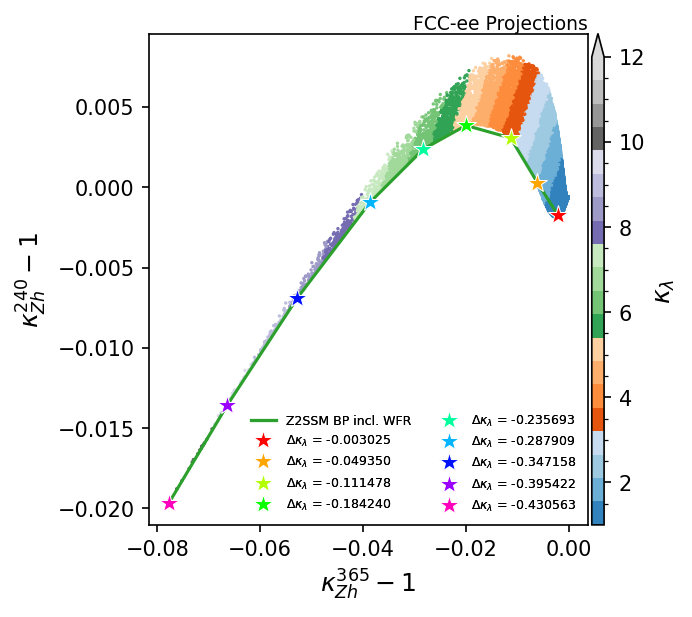

In [23]:
from utils.common_utils import analytical_formula_CH_CHBox as analytical_formula
from utils.common_utils import analytical_formula_CH_CHBox_general_C1

plot_points_analytical_formula = []
for BP, label in zip(bp_kappas, BP_Names_legend):
    # k_ZH_365 = sqrt( (BP["ZZ_365"])**2 + ZZh_hextleg( BP["lam"] ) )
    k_ZH_365 = BP["ZZ_365_with_WFR"] 
    # k_ZH_240 = sqrt( (BP["ZZ_240"])**2 + ZZh_hextleg( BP["lam"] ) )
    k_ZH_240 = BP["ZZ_240_with_WFR"] 
    CH, CHBox, lmbd = analytical_formula(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)

    plot_points_analytical_formula.append((k_ZH_365-1, k_ZH_240-1, BP["lam"]-lmbd, label))

plot_points_analytical_formula = [plot_points_analytical_formula[i] for i in BP_indices_for_curve]
data_sets = [plot_points_analytical_formula,]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file, func_read_file_args={"data_with_WFR": True},
                        no_model_text=True, upper_right_text=upper_right_text, 
                        max_num_bulk_points=max_num_bulk_points,
                )

plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_analytical.pdf")

# Cross-checks using the HEPfit SMEFT expressions for the Z2SSM points
We can repeat the process above, but instead of using the Z2SSM predictions for $\kappa_{Zh}^{240}$, $\kappa_{Zh}^{365}$, we use the SMEFT expressions in HEPfit. The `smeft_sigma_Zh` function implements the $\kappa_\lambda$-dependent part of these expressions. Additionally, the BSM corrections to the Higgs external leg, the Z2SSM contribution corresponding to $C_{H□}$, are also added separately. Since these correspond to the Higgs coupling modifier to fermions, for simplicity we take it directly as `2*(BP["uu"]-1))`.

With these predictions, we then use both the interpolating procedure and the inverse of the HEPfit analytical formulas to obtain corresponding SMEFT predictions for $\kappa_\lambda$ for each Z2SSM BP. Since we are now using the HEPfit expressions themselves to obtain the "Z2SSM" predictions for $\kappa_{Zh}$, we expect that the $\kappa_\lambda$ prediction for each Z2SSM BP will match the SMEFT value extracted using these procedures. 

Compare `smeft_formula` Z2SSM predictions with self-consistent SMEFT with $C_H \neq 0$

Processing data file: data/Z2SSM/Z2SSM_scan_combined


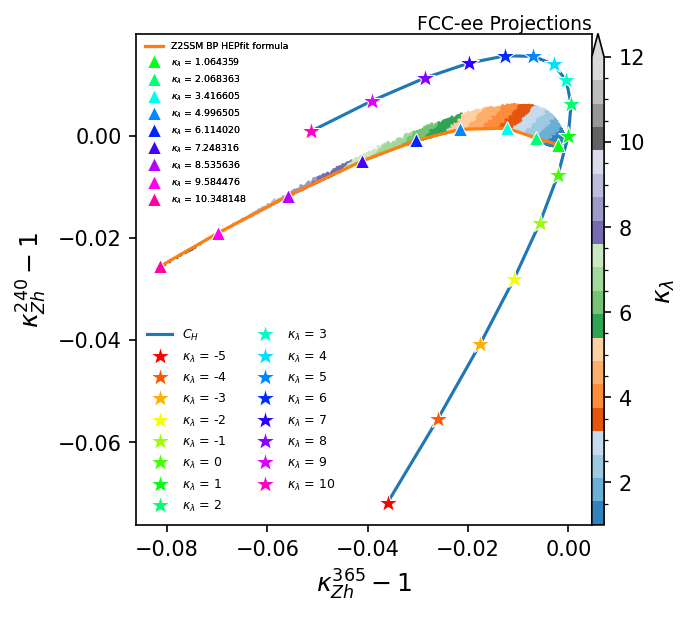

In [24]:
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas, BP_Names_legend)]

plot_points_HEPfit_formula = [
    (sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1)) - 1,
     sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1)) - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]

# Plot only the even-numbered BPBs
plot_points = [plot_points[i] for i in BP_indices_for_curve]
plot_points_HEPfit_formula = [plot_points_HEPfit_formula[i] for i in BP_indices_for_curve]

plot_name = "Z2SSM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_SMEFT_formula"

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={"data_with_WFR_HEPfit_C1_values": True},
                )

curves = ["CH", "Z2SSM_HEPfit",]
file_names = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions.txt",
    # "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits_CHbox/comparison_plots/k_ZH_240_365_predictions.txt",
    None,
]
data_sets = [None, plot_points_HEPfit_formula,]
legend_locs = ['lower left', 'upper left',]
legend_cols = [2, 1,]
legend_fontsizes = [6.0, 4.5,]
markers = ["*", "^",]
color_lines = ["tab:blue", "tab:orange",]
label_lines = [r'$C_{H}$', r'Z2SSM BP HEPfit formula',]
markersizes = [10, 7,]

plot_curves(ax, curves, file_names, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")


Instead of using SMEFT predictions corresponding to integer values of $\kappa_\lambda$, obtain predictions for the same values of $\kappa_\lambda$ as the Z2SSM benchmarks:

Processing data file: data/Z2SSM/Z2SSM_scan_combined


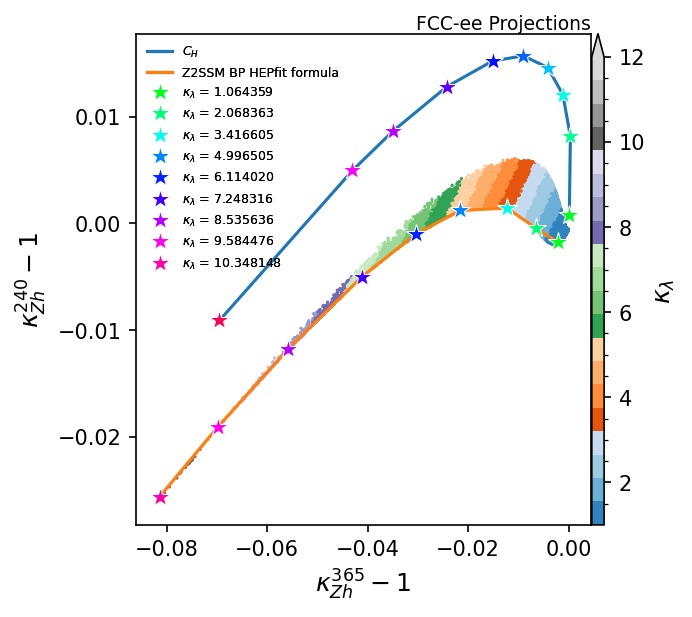

In [25]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file, 
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={"data_with_WFR_HEPfit_C1_values": True},
                )

legend_locs = [None, 'upper left',]
legend_fontsizes = [6.0, 6.0,]
markers = ["*", "*", ]
markersizes = [10, 10, ]
curves_matching_lambdas = ["CH_matching_lambdas", "Z2SSM_HEPfit"]
file_names_matching_lambdas = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions_general_lambdas.txt",
    None,
]
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas.pdf")

#### Cross-check using interpolation in the $C_H$ vs. $C_{H□}$ plane

plot_points_interpolation = [(-0.0021259110544075144, -0.0017615720041123106, nan, 'New BPB 0'), (-0.006511397340792091, -0.00045405176776336376, 3.994291414954887e-06, 'New BPB 1'), (-0.012316337307212821, 0.0014123283246945117, -0.0001704701181015622, 'New BPB 2'), (-0.021699558404005614, 0.0011155052803724086, -0.0005837795760541553, 'New BPB 4'), (-0.030485654306032228, -0.001127390284094254, -0.000581736001850075, 'New BPB 6'), (-0.041366290812768214, -0.005221349088021854, -0.0004693771220978249, 'New BPB 8'), (-0.05620594859547223, -0.012123541393899595, -0.0003917520939644703, 'New BPB 10'), (-0.07033512983611567, -0.019550432501588055, -0.0007524543595724964, 'New BPB 12'), (-0.08202551683999626, -0.026187274018113937, -0.000762744806580784, 'New BPB 13')]
Processing data file: data/Z2SSM/Z2SSM_scan_combined


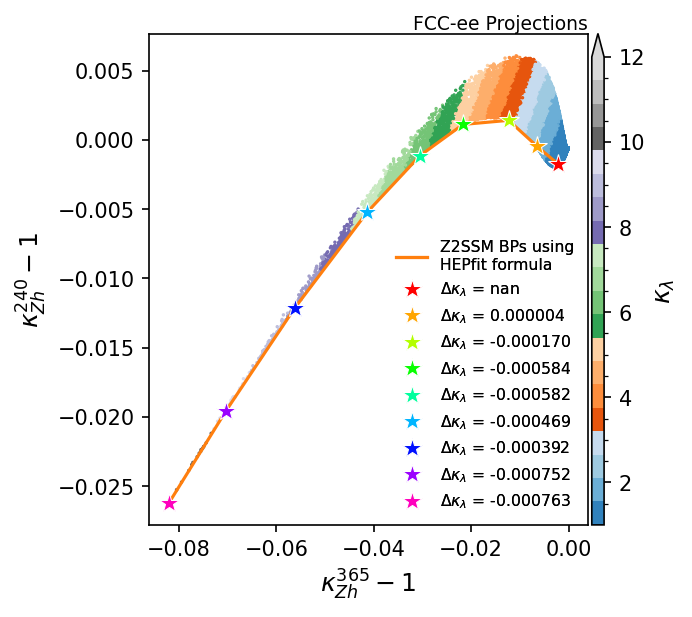

In [26]:
x = np.array([BP["ZZ_365_with_WFR_HEPfit_C1_values"] - 1 for BP in bp_kappas])
y = np.array([BP["ZZ_240_with_WFR_HEPfit_C1_values"] - 1 for BP in bp_kappas])
# x = np.array([sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1)) - 1 for BP in bp_kappas])
# y = np.array([sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1)) - 1 for BP in bp_kappas])
lmbd_BPs = np.array([BP["lam"] for BP in bp_kappas])

X, Y = np.meshgrid(np.array(x)+1, np.array(y)+1)  # 2D grid for interpolation
Z = interp(X, Y)
Z = np.array([Z[i,i] for i in range(Z.shape[0])])

plot_points_interpolation = tuple(zip(x, y, lmbd_BPs-Z, BP_Names_legend))
plot_points_interpolation = [plot_points_interpolation[i] for i in BP_indices_for_curve]
print(f"plot_points_interpolation = {plot_points_interpolation}")

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
    no_model_text=True, upper_right_text=upper_right_text,
    max_num_bulk_points=max_num_bulk_points,
    func_read_file_args={'data_with_WFR_HEPfit_C1_values': True},
)

data_sets = [plot_points_interpolation,]
legend_locs = ['lower right',]
legend_fontsizes = [6.0,]
markers = ["*", ]
markersizes = [10, ]
curves_matching_lambdas = ["Z2SSM_HEPfit",]
file_names_matching_lambdas = [None,]
color_lines = ["tab:orange",]
label_lines = ['Z2SSM BPs using\nHEPfit formula',]
legend_cols = [1,]
legend_fontsizes = [7.5,]
klam_in_point_labels = r"$\Delta \kappa_{\lambda}$"
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_interp.pdf")

#### Cross-check using analytical formula

Processing data file: data/Z2SSM/Z2SSM_scan_combined


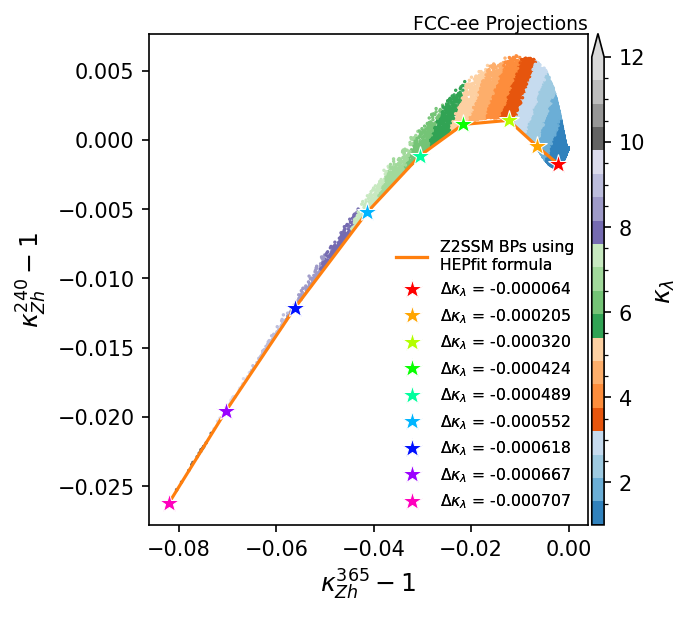

In [27]:
plot_points_analytical_formula = []
for BP, label in zip(bp_kappas, BP_Names_legend):
    k_ZH_365 = BP["ZZ_365_with_WFR_HEPfit_C1_values"]
    k_ZH_240 = BP["ZZ_240_with_WFR_HEPfit_C1_values"]
    CH, CHBox, lmbd = analytical_formula(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)

    plot_points_analytical_formula.append((k_ZH_365-1, k_ZH_240-1, BP["lam"]-lmbd, label))

plot_points_analytical_formula = [plot_points_analytical_formula[i] for i in BP_indices_for_curve]
data_sets = [plot_points_analytical_formula,]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={'data_with_WFR_HEPfit_C1_values': True},
                )

plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_analytical.pdf")

## Interpolation of $C_H$ vs. $C_{H□}$ curve
We have obtained ($C_H, C_{H□}$) pairs for each Z2SSM BP, by inverting the SMEFT HEPfit expressions. Here we interpolate the relationship between $C_H$ and $C_{H□}$, using a piecewise-linear function.

CH values for Z2SSM BPs: [ -0.1512492   -2.31992775  -5.21581966  -8.6025334  -10.99633116
 -13.4251333  -16.18049951 -18.42454666 -20.05914483]
CH values for Z2SSM BPs (sorted): [-20.05914483 -18.42454666 -16.18049951 -13.4251333  -10.99633116
  -8.6025334   -5.21581966  -2.31992775  -0.1512492 ]
CHbox values for Z2SSM BPs: [-0.03637485 -0.11583032 -0.18070375 -0.23944392 -0.27655066 -0.31180435
 -0.34901418 -0.37707772 -0.39926069]
CHbox values for Z2SSM BPs (sorted): [-0.39926069 -0.37707772 -0.34901418 -0.31180435 -0.27655066 -0.23944392
 -0.18070375 -0.11583032 -0.03637485]
CH curve: [-20.  -19.2 -18.4 -17.6 -16.8 -16.  -15.2 -14.4 -13.6 -12.8 -12.  -11.2
 -10.4  -9.6  -8.8  -8.   -7.2  -6.4  -5.6  -4.8  -4.   -3.2  -2.4  -1.6
  -0.8   0. ]
CHbox curve: [-0.39845804 -0.38760132 -0.37677074 -0.36676613 -0.35676151 -0.34657663
 -0.33577303 -0.32496943 -0.31416583 -0.30273063 -0.29111876 -0.27950689
 -0.26730681 -0.25490585 -0.24250489 -0.2289934  -0.21511796 -0.20124253
 -0.18736709

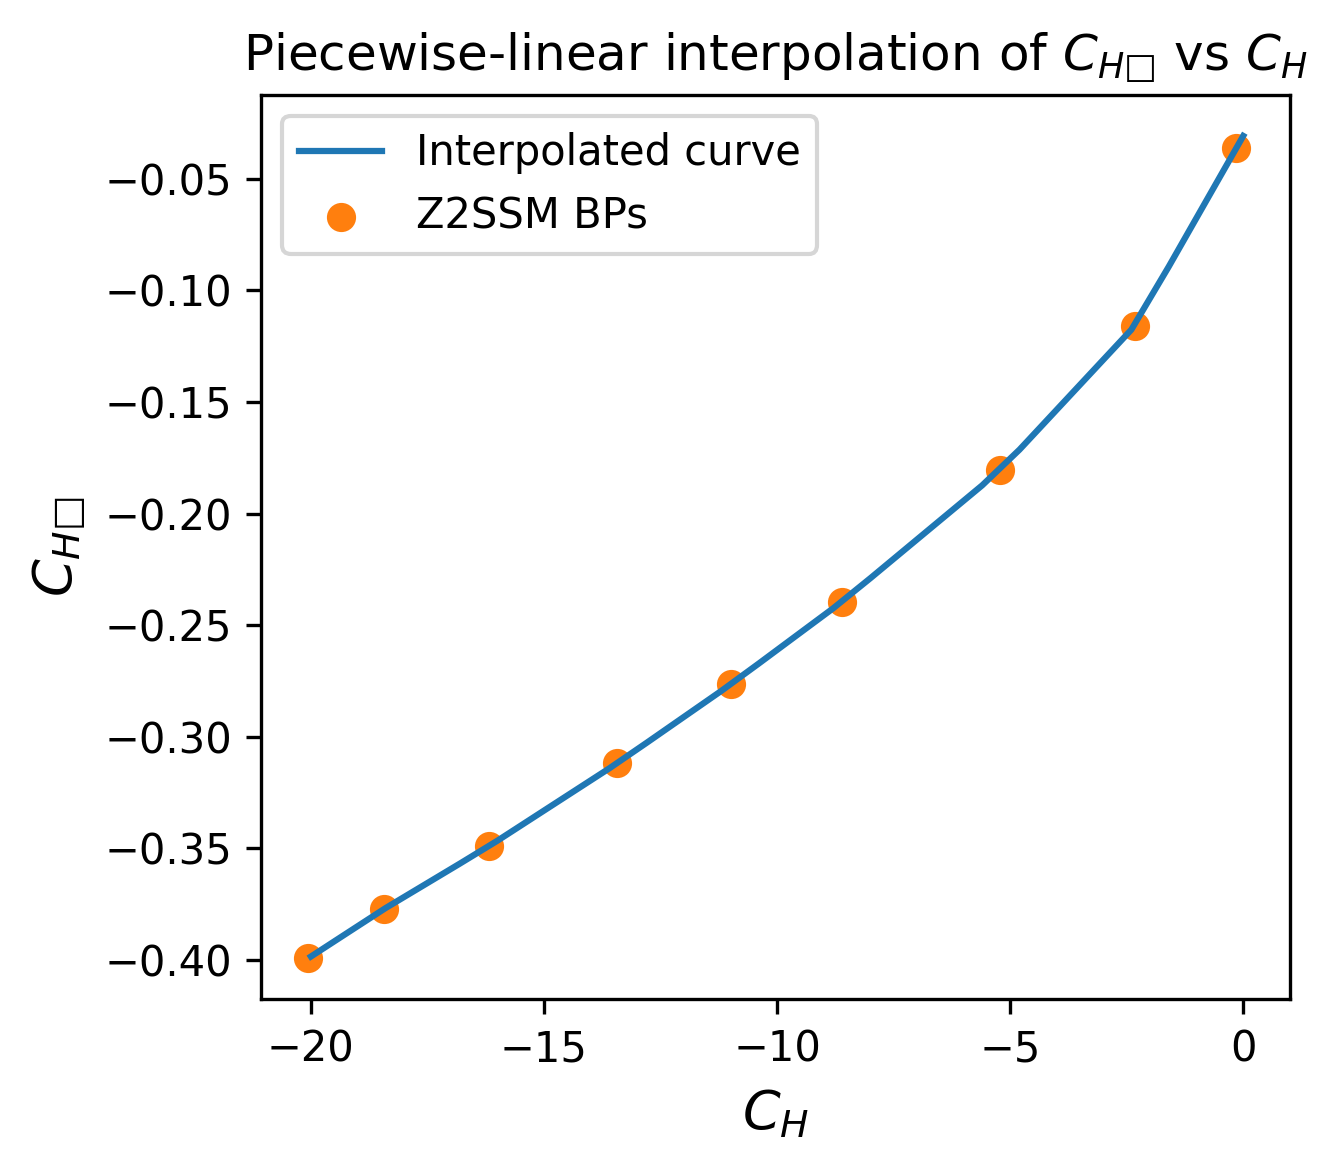

In [28]:
# from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline

CH_BPs = []
CHbox_BPs = []
for BP in bp_kappas:
    k_ZH_365 = BP["ZZ_365_with_WFR_HEPfit_C1_values"]
    k_ZH_240 = BP["ZZ_240_with_WFR_HEPfit_C1_values"]
    CH, CHBox, lmbd = analytical_formula(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)
    CH_BPs.append(CH)
    CHbox_BPs.append(CHBox)

CH_BPs = np.array([CH_BPs[i] for i in BP_indices_for_curve])
CHbox_BPs = np.array([CHbox_BPs[i] for i in BP_indices_for_curve])

sorted_indices = np.argsort(CH_BPs)
CH_BPs_sorted = CH_BPs[sorted_indices]
CHbox_BPs_sorted = CHbox_BPs[sorted_indices]

print(f"CH values for Z2SSM BPs: {CH_BPs}")
print(f"CH values for Z2SSM BPs (sorted): {CH_BPs_sorted}")
print(f"CHbox values for Z2SSM BPs: {CHbox_BPs}")
print(f"CHbox values for Z2SSM BPs (sorted): {CHbox_BPs_sorted}")
# CH_CHbox_interpolator = CubicSpline(CH_BPs_sorted, CHbox_BPs_sorted)
spline_degree = 1  # Linear interpolation
CH_CHbox_interpolator = make_interp_spline(CH_BPs_sorted, CHbox_BPs_sorted, k=spline_degree)

CH_curve = np.linspace(-20, 0, 26)
CHbox_curve = CH_CHbox_interpolator(CH_curve)
print(f"CH curve: {CH_curve}")
print(f"CHbox curve: {CHbox_curve}")

fig, ax = plt.subplots(figsize=(4.5, 4.),dpi=300)
plt.plot(CH_curve, CHbox_curve, label="Interpolated curve", color="tab:blue")
plt.scatter(CH_BPs, CHbox_BPs, color="tab:orange", label="Z2SSM BPs")
plt.xlabel(r"$C_{H}$", fontsize=13)
plt.ylabel('$C_{H\u25A1}$', fontsize=13)
# plt.title("Cubic spline interpolation of $C_{H\u25A1}$ vs $C_{H}$")
plt.title("Piecewise-linear interpolation of $C_{H\u25A1}$ vs $C_{H}$")
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"_CH_CHbox_Cubic_spline_interpolation.pdf")


output_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/"
with open(f"{output_dir}/CH_CHbox_interpolator_results.txt", "w") as f:
    for i in range(len(CH_curve)):
        f.write(f"{CH_curve[i]},{CHbox_curve[i]}\n")

with open(f"{output_dir}/CH_CHbox_BPs.txt", "w") as f:
    for i in range(len(CH_BPs)):
        f.write(f"{CH_BPs[i]},{CHbox_BPs[i]}\n")


## Plotting results for different calculation methods

Processing data file: data/Z2SSM/Z2SSM_scan_combined
Processing data file: data/Z2SSM/Z2SSM_scan_combined


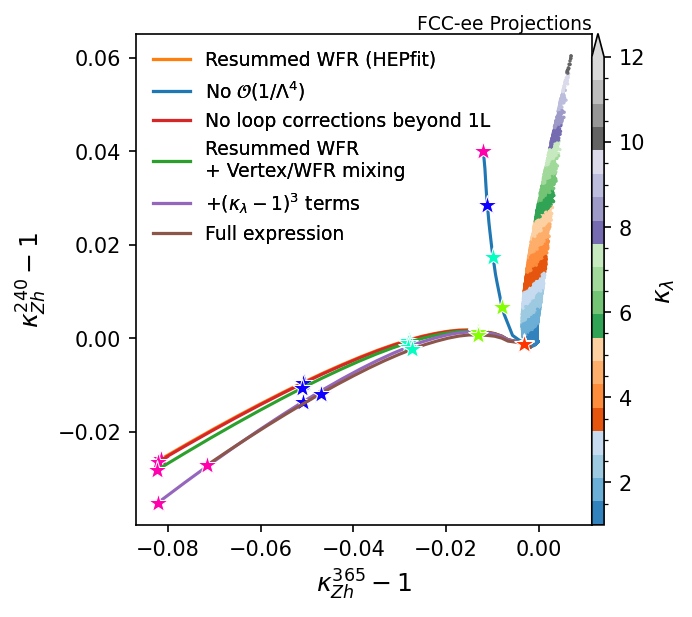

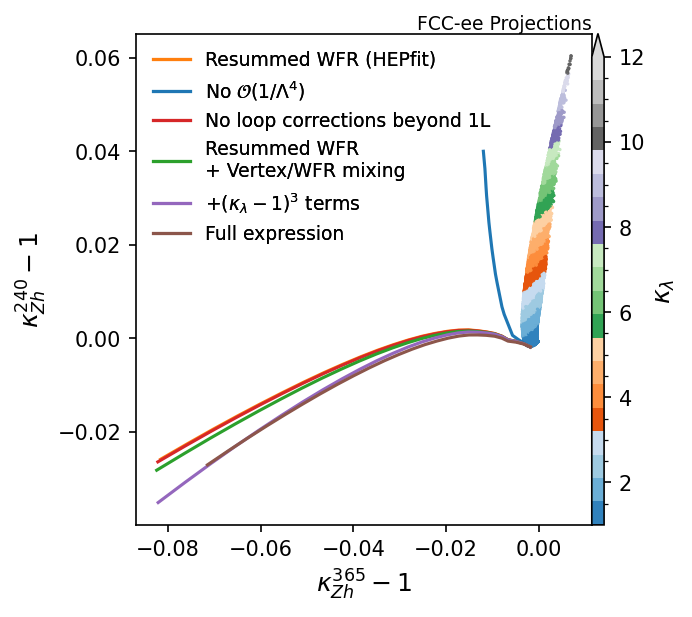

In [29]:
plot_name = "Z2SSM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_SMEFT_formula"

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                )

legend_locs = [None, None, None, None, None, "upper left",]
legend_cols = [1 for _ in range(6)]
legend_fontsizes = [9.0 for _ in range(6)]
markers = ["*" for _ in range(6)]
markersizes = [10.0 for _ in range(6)]
color_lines = [
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [None for _ in range(6)]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    f"{results_directory}/k_ZH_240_365_predictions.txt",
    f"{results_directory}/k_ZH_240_365_predictions_noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Full.txt",
]

plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    max_n_markers=5,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_markers.pdf")


fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                )
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    [None for _ in range(6)],  # No markers for this plot
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation.pdf")

### Plots including SM higgs contribution to WFR into Z2SSM BPs

Processing data file: data/Z2SSM/Z2SSM_scan_combined
Processing data file: data/Z2SSM/Z2SSM_scan_combined


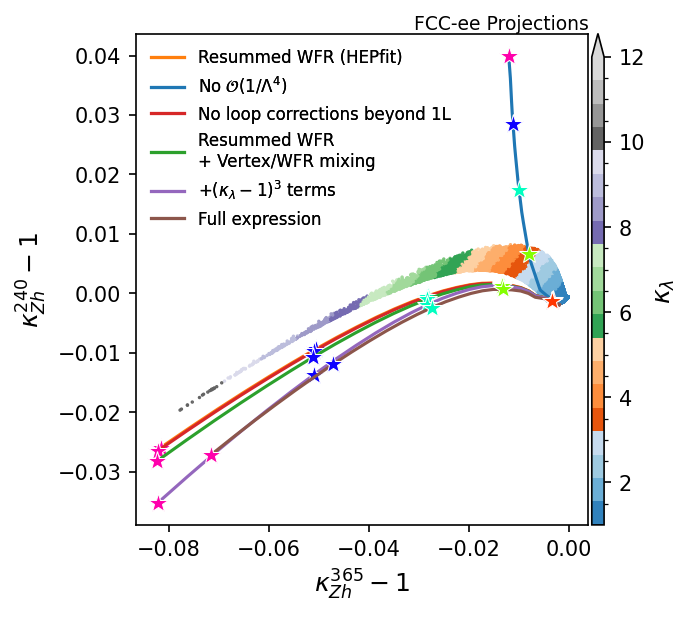

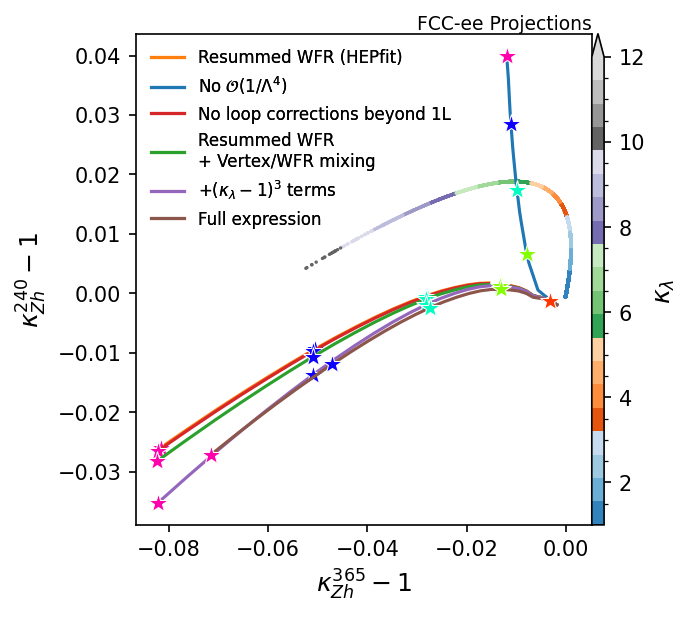

In [30]:
legend_fontsizes = [8.0 for _ in range(6)]

#####################
### data_with_WFR ###
#####################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={'data_with_WFR': True},
)
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    max_n_markers=5,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_markers_with_WFR.pdf")



###################################
###### data_with_WFR_no_BSM #######
###################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={'data_with_WFR': False,
                                             'data_with_WFR_no_BSM': True},
)
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    max_n_markers=5,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_markers_with_WFR_no_BSM.pdf")

### Plots for presentations

Processing data file: data/Z2SSM/Z2SSM_scan_combined


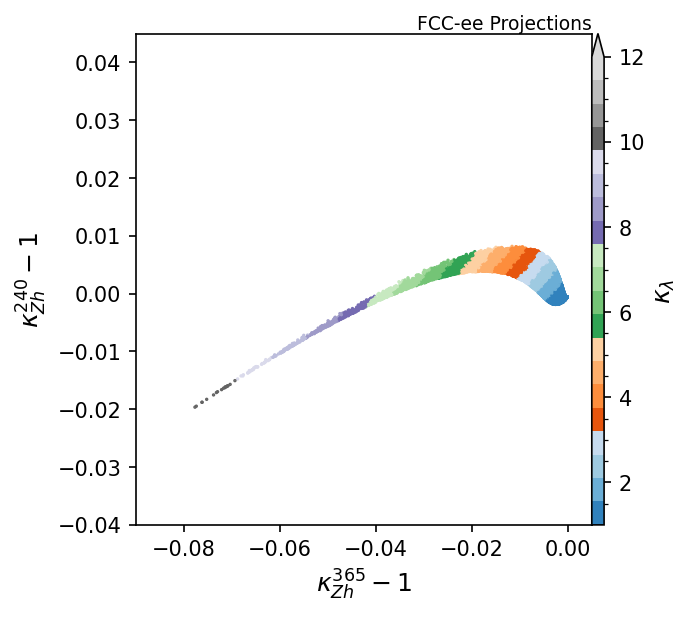

In [31]:
#######################################
############ data_with_WFR ############
#######################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                           'data_with_WFR': True,
                           'data_with_WFR_no_BSM': False,
                       }
                )

legend_locs = []
legend_fontsizes = []
markers = []
markersizes = []
color_lines = []
label_lines = []
legend_cols = []
curves_uncertainty_estimation = []
data_sets = []
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = []
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
final_xlims = (-0.09, +0.005)
final_ylims = (-0.04, +0.045)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=1
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data file: data/Z2SSM/Z2SSM_scan_combined


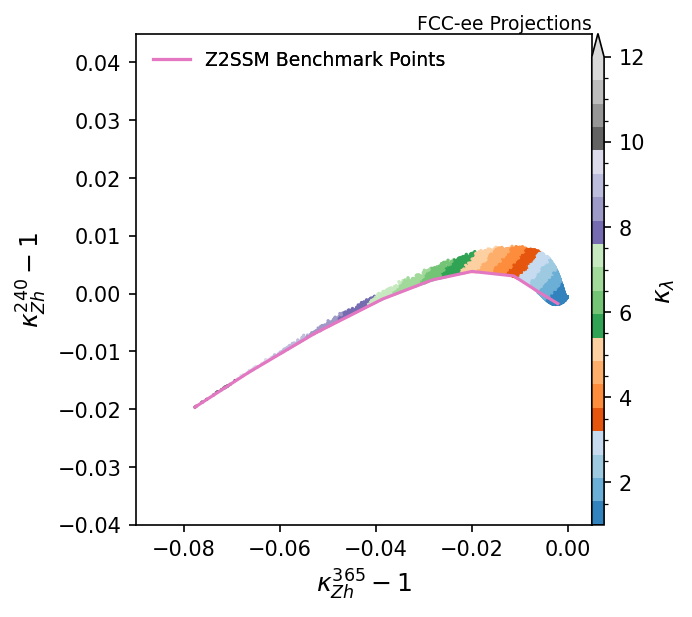

In [32]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM': False,
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = [plot_points_with_WFR[i] for i in BP_indices_for_curve]

legend_locs = ["upper left",]
legend_fontsizes = [9.0,]
markers = [None,]
markersizes = [10,]
color_lines = ["tab:pink",]
label_lines = [r'Z2SSM Benchmark Points',]
legend_cols = [1,]
curves_uncertainty_estimation = ["Z2SSM",]
data_sets = [plot_points_with_WFR,]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [None,]

plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=2
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data file: data/Z2SSM/Z2SSM_scan_combined


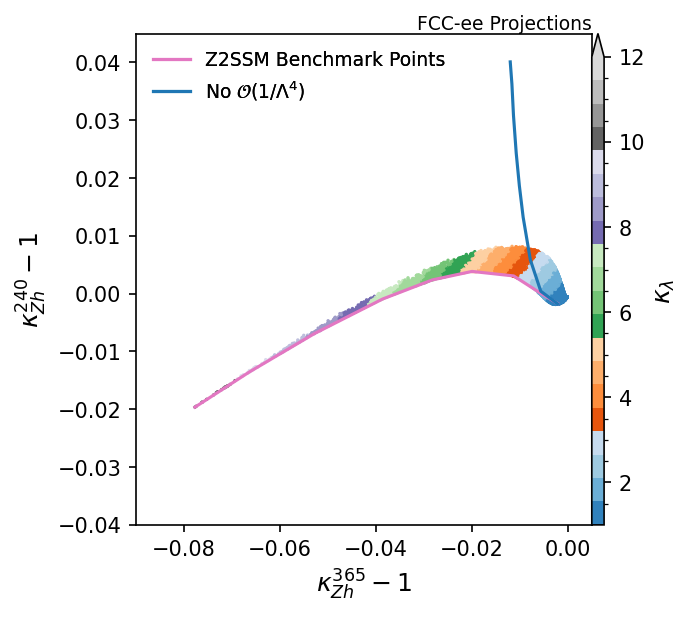

In [33]:
#######################################
############ data_with_WFR ############
#######################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM': False,
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = [plot_points_with_WFR[i] for i in BP_indices_for_curve]
# plot_points_with_WFR = plot_points_with_WFR[::-1] 

legend_locs = [None, "upper left",]
legend_cols = [1, 1,]
legend_fontsizes = [9.0, 9.0,]
markers = [None, None,]
markersizes = [10, 10,]
color_lines = ["tab:pink", "tab:blue",]
label_lines = [
    r'Z2SSM Benchmark Points',
    r'No $\mathcal{O}(1/\Lambda^4)$',
]
curves_uncertainty_estimation = ["Z2SSM", "noLoopH3d6Quad",]
data_sets = [
    plot_points_with_WFR, 
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=3
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data file: data/Z2SSM/Z2SSM_scan_combined


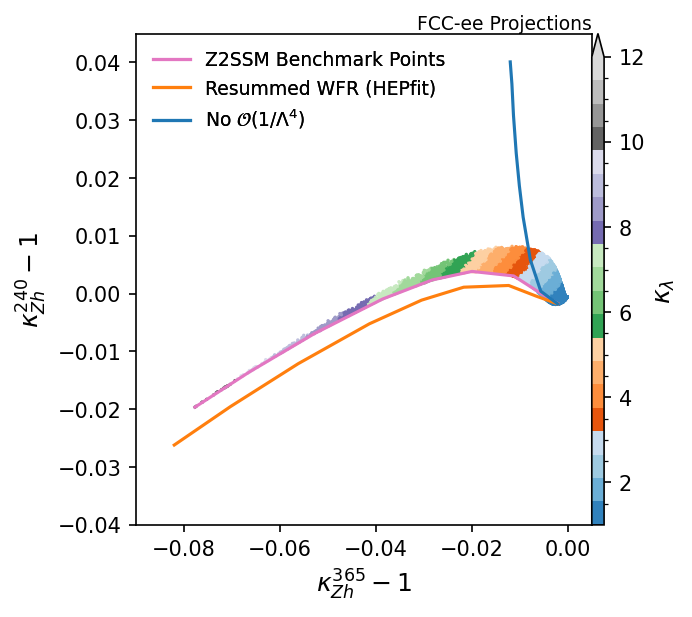

In [34]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM': False,
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = [plot_points_with_WFR[i] for i in BP_indices_for_curve]

legend_locs = [None, None, "upper left",]
legend_cols = [1, 1, 1,]
legend_fontsizes = [9.0, 9.0, 9.0]
markers = [None, None, None,]
markersizes = [10, 10, 10,]
color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
]
label_lines = [
    r'Z2SSM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
]
curves_uncertainty_estimation = [
    "Z2SSM",
    "HEPfit", 
    "noLoopH3d6Quad",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs_.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=4
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data file: data/Z2SSM/Z2SSM_scan_combined


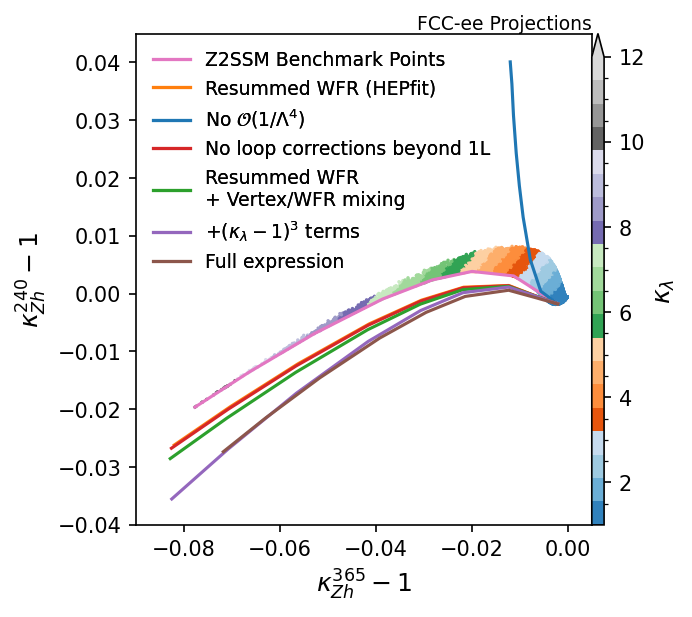

In [35]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM': False,
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = [plot_points_with_WFR[i] for i in BP_indices_for_curve]

color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'Z2SSM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "Z2SSM",
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
    None,
    None,
    None,
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs_.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Full.txt",
]
n_curves = len(curves_uncertainty_estimation)
legend_locs = [None, None, None, None, None, None, "upper left", ]
legend_fontsizes = [ 9.0 for _ in range(n_curves) ]
markers = [ None for _ in range(n_curves) ]
markersizes = [ 10 for _ in range(n_curves) ]
legend_cols = [1 for _ in range(n_curves)]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=5
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

### Estimating uncertainty with ellipses

Processing data file: data/Z2SSM/Z2SSM_scan_combined


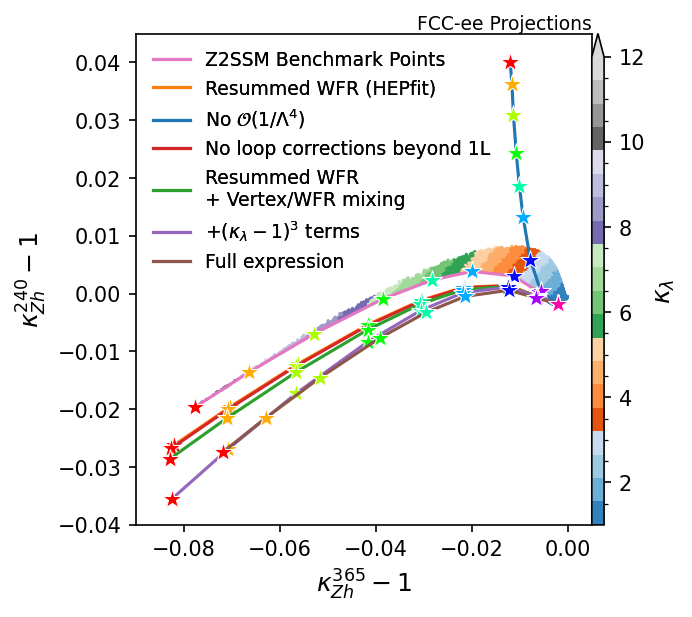

In [36]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM': False,
                        }
                )

markers = [ "*" for _ in range(n_curves) ]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_WFR_BPs.pdf")
plot_name = "Uncertainties_final_plot"; n_plot=6
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data file: data/Z2SSM/Z2SSM_scan_combined


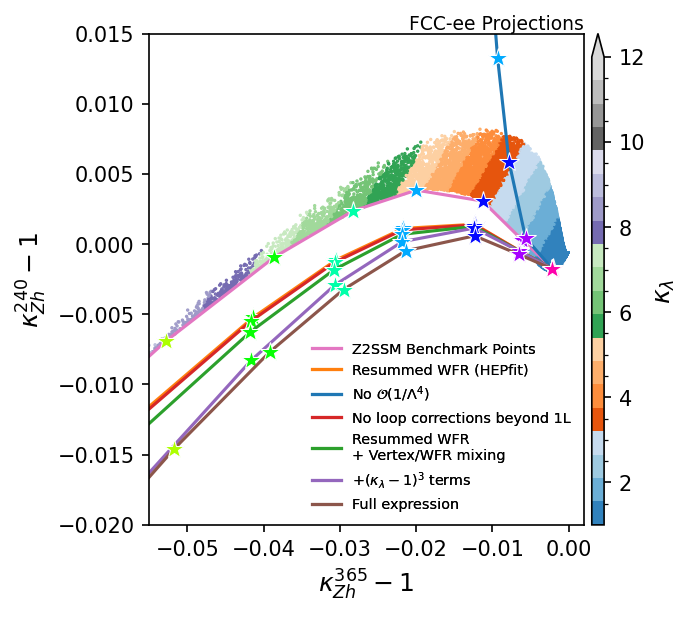

In [37]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM': False,
                        }
                )
n_curves = 7
legend_locs = [None, None, None, None, None, None, 'lower right']
legend_fontsizes = [6.9 for _ in range(n_curves)]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.055, +0.002)
ax.set_ylim(-0.02, +0.015)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_WFR_BPs_zoom.pdf")
plot_name = "Uncertainties_final_plot"; n_plot=7
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

## Ellipse patch for matplotlib legend

In [38]:
from matplotlib.patches import Ellipse, Circle
from matplotlib.legend_handler import HandlerPatch

class HandlerEllipse(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        center = 0.5 * width - 0.5 * xdescent, 0.5 * height - 0.5 * ydescent
        p = Ellipse(xy=center, width=1.2*width + xdescent,
                               height=1.2*height + ydescent)
        self.update_prop(p, orig_handle, legend)
        p.set_transform(trans)
        return [p]

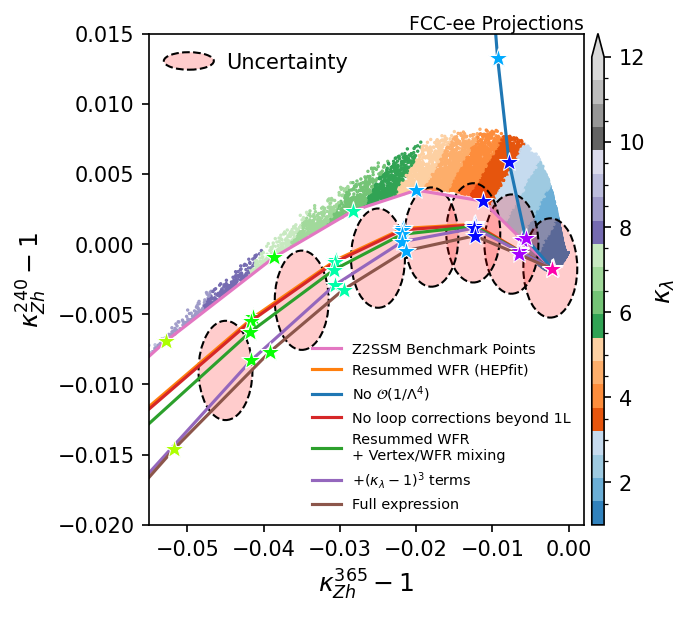

In [39]:
xs     = [-2.4e-3, -0.0075, -0.0125, -0.018, -0.025, -0.035, -0.045, ]
ys     = [-1.7e-3, -0.0e-4, 0.0008,  0.0005, -0.001, -0.004, -0.009, ]
err_xs = [ sqrt(2) * 0.005 / 2. for x in xs]
err_ys = [ sqrt(2) * 0.005 / 2. for x in xs]
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})

fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_WFR_BPs_zoom_ellipses_0.005.pdf")
fig

Processing data file: data/Z2SSM/Z2SSM_scan_combined


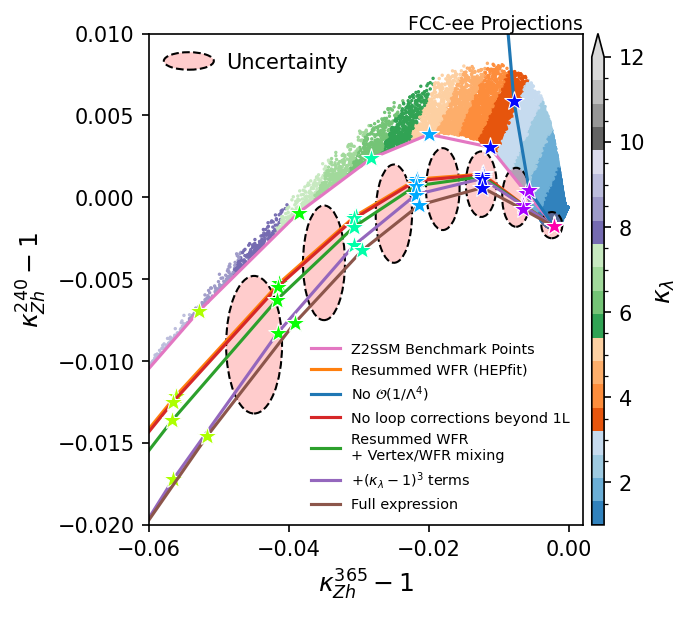

In [40]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM': False,
                        }
                )

plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)

xs     = [-2.4e-3, -0.0075, -0.0125, -0.018, -0.025, -0.035, -0.045, ]
ys     = [-1.7e-3, -0.0e-4, 0.0008,  0.0005, -0.001, -0.004, -0.009, ]
err_xs = [1.5e-3,  2.0e-3, 2.2e-3,  2.4e-3, 2.6e-3, 3.0e-3, 4e-3,   ]
err_ys = [8.0e-4,  1.8e-3, 2.0e-3,  2.5e-3, 3.0e-3, 3.5e-3, 4.2e-3, ] 
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_IDM_WFR_ZZh1L_hextlegonly_BPs_zoom_ellipses.pdf")
plot_name = "Uncertainties_final_plot"; n_plot = 8
fig.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

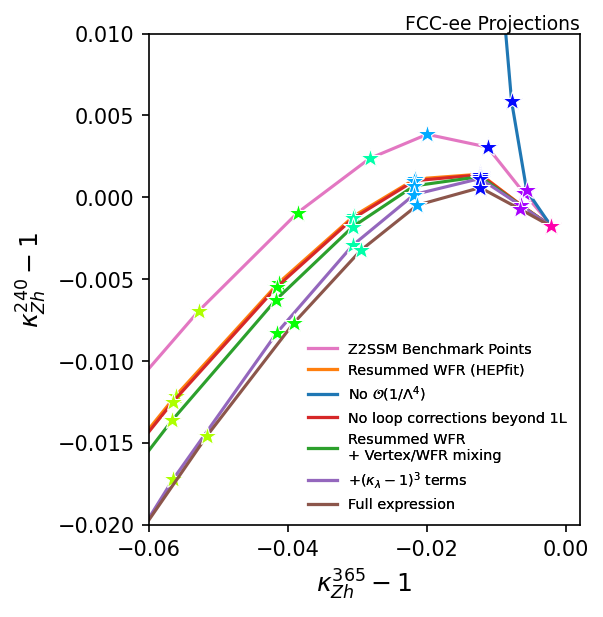

In [41]:
fig, ax = plt.subplots(
    figsize=(3.91, 4.0),
    constrained_layout=True)

ax.set_xlabel(r'$\kappa_{Zh}^{365} - 1$')
ax.set_ylabel(r'$\kappa_{Zh}^{240} - 1$')

text_collider = "FCC-ee Projections"
ax.text(
    1,
    1,
    text_collider,
    horizontalalignment="right",
    verticalalignment="bottom",
    transform=ax.transAxes,
    fontsize=9,
)

legend_locs = [None, None, None, None, None, None, 'lower right',]
legend_fontsizes = [6.9 for _ in range(n_curves)]
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols,
    legend_fontsizes, 
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
plot_name = "Uncertainties_final_plot"; n_plot = 7
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}_alt.pdf")

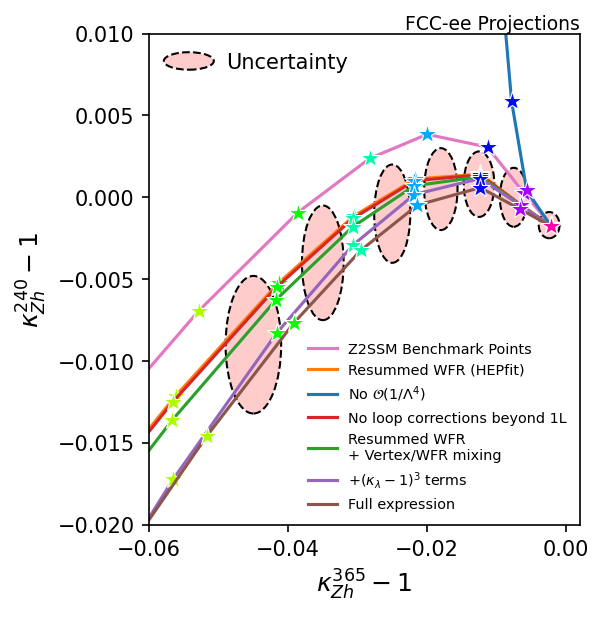

In [42]:
xs     = [-2.4e-3, -0.0075, -0.0125, -0.018, -0.025, -0.035, -0.045, ]
ys     = [-1.7e-3, -0.0e-4, 0.0008,  0.0005, -0.001, -0.004, -0.009, ]
err_xs = [1.5e-3,  2.0e-3, 2.2e-3,  2.4e-3, 2.6e-3, 3.0e-3, 4e-3,   ]
err_ys = [8.0e-4,  1.8e-3, 2.0e-3,  2.5e-3, 3.0e-3, 3.5e-3, 4.2e-3, ] 
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)
    
ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
plot_name = "Uncertainties_final_plot"; n_plot = 8
fig.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}_alt.pdf")
fig

### Using ellipses parameters as estimates for new nuisance parameters

klam = [1.0643594459030925, 2.068362744578383, 3.41660475844658, 4.996504503173265, 6.114019817191308, 7.24831645311373, 8.535635929341407]
Mean k_Zh uncertainties: 240: 0.0011625, 365: 0.00115
kappas_Zh_365 = [0.9979014848798298, 0.9939452822115468, 0.9887224220899075, 0.980034161481392, 0.971752359298989, 0.9613983585380317, 0.9471795291909567, 0.9335789496816949, 0.9222899806275258]
kappas_Zh_240 = [0.9982825747303763, 1.0002775710382483, 1.0030633964626312, 1.0038453288843006, 1.0023722414852438, 0.9990703663610583, 0.9930860519358344, 0.9864267557084154, 0.9803639421790961]
mean_kappas_Zh = [0.9801696476234295, 1.0030936556107253]
Mean sigma_Zh uncertainties: 240: 0.0023321927492949363, 365: 0.002254390189533888


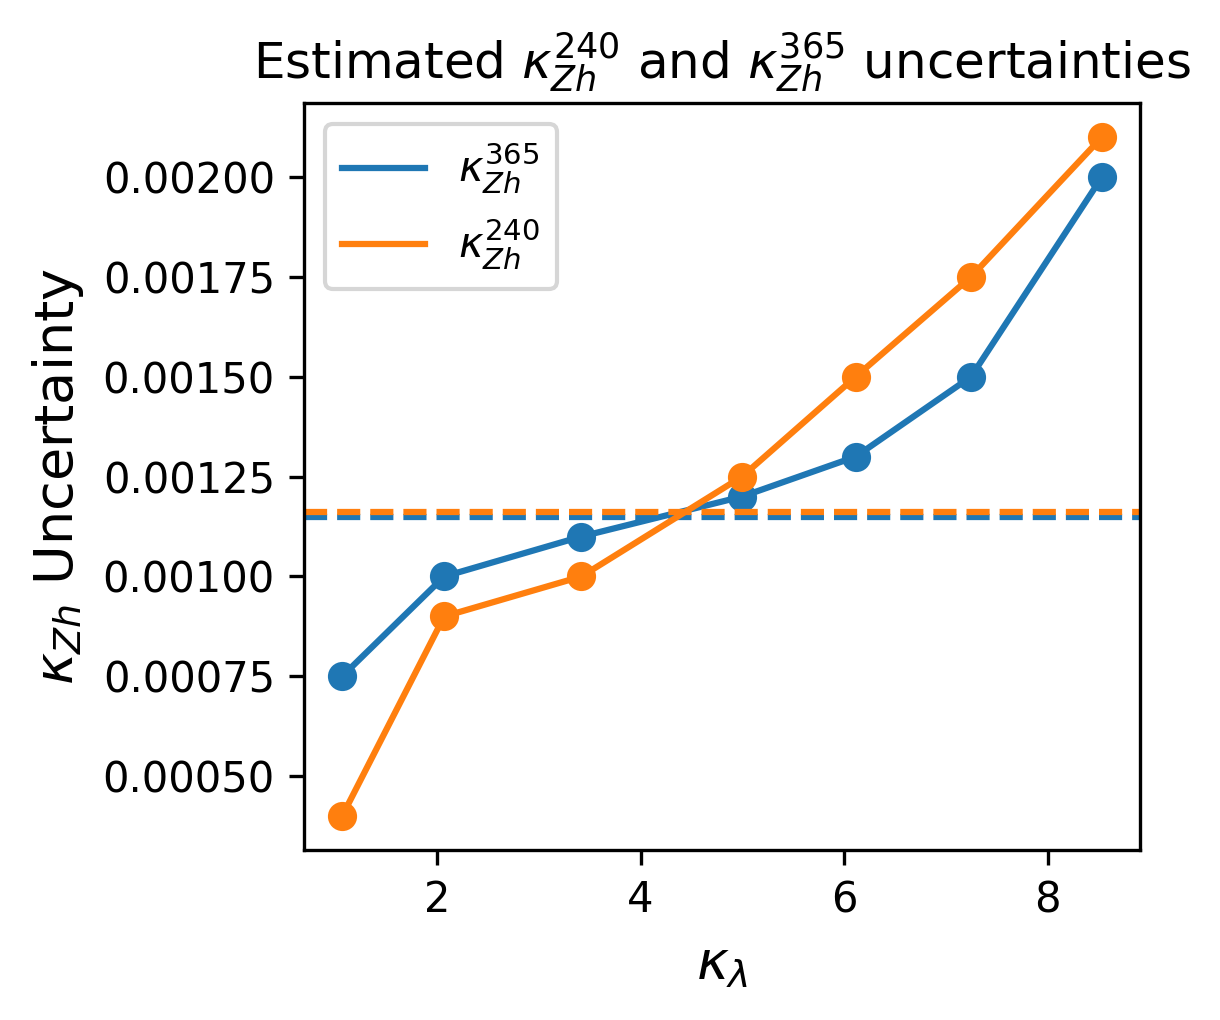

In [43]:
fig, ax = plt.subplots(figsize=(4.0, 3.5), dpi=300)
curves = [0.5*np.array(err_xs), 0.5*np.array(err_ys)]
labels = [r"$\kappa_{Zh}^{365}$", r"$\kappa_{Zh}^{240}$"]
colors = ["tab:blue", "tab:orange",]

mean_uncertainties_kappa = [np.mean(curve[1:5]) for curve in curves]

klam = [ plot_points_with_WFR[i][2] for i in range(len(err_xs)) ]
print(f"klam = {klam}")
for curve, label, color, mean in zip(curves, labels, colors, mean_uncertainties_kappa):
    plt.plot(klam, curve, label=label, color=color)
    plt.scatter(klam, curve, color=color)

    plt.axhline(y=mean, linestyle='--', linewidth=1.5, color=color)
    
plt.xlabel(r"$\kappa_\lambda$", fontsize=13)
plt.title(r"Estimated $\kappa_{Zh}^{240}$ and $\kappa_{Zh}^{365}$ uncertainties")
plt.ylabel(r"$\kappa_{Zh}$ Uncertainty", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"k_ZH_240_365_uncertainties.pdf")

print(f"Mean k_Zh uncertainties: 240: {mean_uncertainties_kappa[1]}, 365: {mean_uncertainties_kappa[0]}")
kappas_Zh_365 = [ (lst[0]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_365 = {kappas_Zh_365}")
kappas_Zh_240 = [ (lst[1]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_240 = {kappas_Zh_240}")
kappas_Zh = [ kappas_Zh_365[1:5], kappas_Zh_240[1:5]]

mean_kappas_Zh = [np.mean(ks[1:5]) for ks in kappas_Zh]
print(f"mean_kappas_Zh = {mean_kappas_Zh}")
mean_uncertainties_sigma = [2*kappa*mean for kappa, mean in zip(mean_kappas_Zh, mean_uncertainties_kappa)]
print(f"Mean sigma_Zh uncertainties: 240: {mean_uncertainties_sigma[1]}, 365: {mean_uncertainties_sigma[0]}")

In [45]:
raise NotImplementedError("Code below is not yet updated to Z2SSM")

NotImplementedError: Code below is not yet updated to Z2SSM

# Second set of nuisance parameters: `NP_mismatch`

### Interpolation including more Wilson coefficients

In [44]:
# from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline

CH_BPs = []
CHbox_BPs = []
CHD_BPs = []
CHW_BPs = []
CHB_BPs = []
CHWB_BPs = []
input_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/all_WCs/"
with open(f"{input_dir}WC_results.txt", 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if i == 0:  # Skip header line
            continue

        _, CH, CHbox, CHD, CHW, CHB, CHWB = line.split(",")
        CH_BPs.append(float(CH))
        CHbox_BPs.append(float(CHbox))
        CHD_BPs.append(float(CHD))
        CHW_BPs.append(float(CHW))
        CHB_BPs.append(float(CHB))
        CHWB_BPs.append(float(CHWB))

CH_BPs    = np.array(CH_BPs[0::2])
CHbox_BPs = np.array(CHbox_BPs[0::2])
CHD_BPs   = np.array(CHD_BPs[0::2])
CHW_BPs   = np.array(CHW_BPs[0::2])
CHB_BPs   = np.array(CHB_BPs[0::2])
CHWB_BPs  = np.array(CHWB_BPs[0::2])

print(f"CH_BPs: {CH_BPs}")
print(f"CHbox_BPs: {CHbox_BPs}")
print(f"CHD_BPs: {CHD_BPs}")
print(f"CHW_BPs: {CHW_BPs}")
print(f"CHB_BPs: {CHB_BPs}")
print(f"CHWB_BPs: {CHWB_BPs}")

sorted_indices = np.argsort(CH_BPs)
print(f"Sorted indices: {sorted_indices}")
CH_BPs_sorted    = CH_BPs[sorted_indices]
CHbox_BPs_sorted = CHbox_BPs[sorted_indices]
CHD_BPs_sorted   = CHD_BPs[sorted_indices]
CHW_BPs_sorted   = CHW_BPs[sorted_indices]
CHB_BPs_sorted   = CHB_BPs[sorted_indices]
CHWB_BPs_sorted  = CHWB_BPs[sorted_indices]

# print(f"CH values for Z2SSM BPs: {CH_BPs}")
# print(f"CH values for Z2SSM BPs (sorted): {CH_BPs_sorted}")
# print(f"CHbox values for Z2SSM BPs: {CHbox_BPs}")
# print(f"CHbox values for Z2SSM BPs (sorted): {CHbox_BPs_sorted}")
spline_degree = 1  # Linear interpolation
CH_CHbox_interpolator = make_interp_spline(CH_BPs_sorted, CHbox_BPs_sorted, k=spline_degree)
CH_CHD_interpolator   = make_interp_spline(CH_BPs_sorted, CHD_BPs_sorted,   k=spline_degree)
CH_CHW_interpolator   = make_interp_spline(CH_BPs_sorted, CHW_BPs_sorted,   k=spline_degree)
CH_CHB_interpolator   = make_interp_spline(CH_BPs_sorted, CHB_BPs_sorted,   k=spline_degree)
CH_CHWB_interpolator  = make_interp_spline(CH_BPs_sorted, CHWB_BPs_sorted,  k=spline_degree)

CH_curve = np.linspace(-32, 0, 50)
CHbox_curve = CH_CHbox_interpolator(CH_curve)
CHD_curve   = CH_CHD_interpolator(CH_curve)
CHW_curve   = CH_CHW_interpolator(CH_curve)
CHB_curve   = CH_CHB_interpolator(CH_curve)
CHWB_curve  = CH_CHWB_interpolator(CH_curve)
# print(f"CH curve: {CH_curve}")
# print(f"CHbox curve: {CHbox_curve}")

WC_curves_plot = [CHbox_curve, 10*CHD_curve, 10*CHW_curve, 10*CHB_curve, 10*CHWB_curve]
WC_BPs_plot = [CHbox_BPs, 10*CHD_BPs, 10*CHW_BPs, 10*CHB_BPs, 10*CHWB_BPs]
WC_tex_labels = ["$C_{H\u25A1}$", r"$10\cdot C_{HD}$", r"$10\cdot C_{HW}$", r"$10\cdot C_{HB}$", r"$10\cdot C_{HWB}$"]
colors = ["tab:blue", "tab:green", "tab:red", "tab:purple", "tab:orange"]

fig, ax = plt.subplots(figsize=(4.5, 4.),dpi=300)

for WC_curve, WC_BP, tex_label, color in zip(WC_curves_plot, WC_BPs_plot, WC_tex_labels, colors):
    # plt.plot(CH_curve, WC_curve, label=r"Interpolated curve "+tex_label, color=color)
    plt.plot(CH_curve, WC_curve, label=tex_label, color=color)
    plt.scatter(CH_BPs, WC_BP, color=color)
    
plot_name = "Z2SSM_results_k_ZH_240_vs_365"
plt.xlabel(r"$C_{H}$", fontsize=13)
plt.title(r"Piecewise-linear interpolation of Wilson Coefficients vs $C_{H}$")
plt.ylabel(r"Wilson Coefficient", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"_WCs_linear_interpolation.pdf")

WC_curves = [CHbox_curve, CHD_curve, CHW_curve, CHB_curve, CHWB_curve]
WC_BPs = [CHbox_BPs, CHD_BPs, CHW_BPs, CHB_BPs, CHWB_BPs]

output_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/all_WCs"
with open(f"{output_dir}/WC_interpolator_results.txt", "w") as f:
    print(f"CH,CHbox,CHD,CHW,CHB,CHWB", file=f)
    for i in range(len(CH_curve)):
        f.write(f"{CH_curve[i]},{CHbox_curve[i]},{CHD_curve[i]},{CHW_curve[i]},{CHB_curve[i]},{CHWB_curve[i]}\n")

FileNotFoundError: [Errno 2] No such file or directory: '/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/all_WCs/WC_results.txt'

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


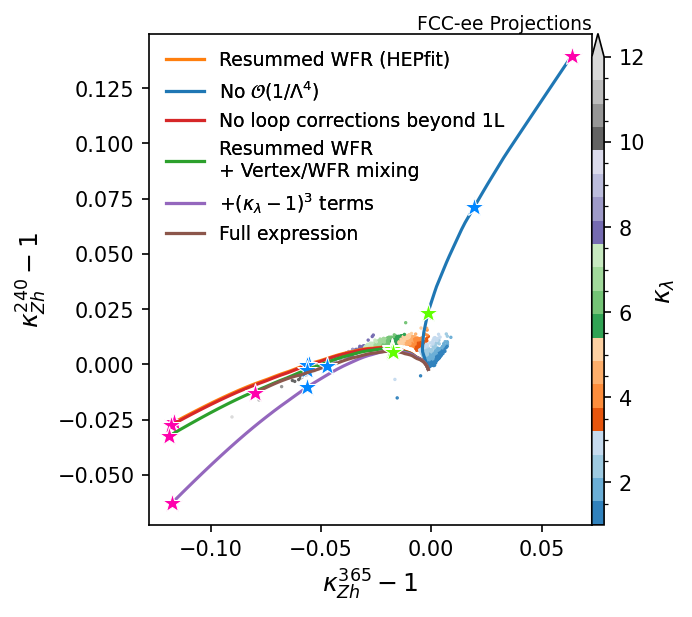

In [ ]:
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/all_WCs/comparison_plots"
plot_name = "IDM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_SMEFT_formula"
k_ZH_240_365_predictions_file_names_all_WCs = [
    f"{results_directory}/k_ZH_240_365_predictions.txt",
    f"{results_directory}/k_ZH_240_365_predictions_noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Full.txt",
]
n_curves = len(k_ZH_240_365_predictions_file_names_all_WCs)

legend_locs = [None, None, None, None, None, "upper left",]
legend_cols = [1 for _ in range(n_curves)]
legend_fontsizes = [9.0 for _ in range(n_curves)]
markers = ["*" for _ in range(n_curves)]
markersizes = [10 for _ in range(n_curves)]
color_lines = [
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    None,
    None,
    None,
    None,
    None,
    None,
]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    max_n_markers=3,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_all_WCs_markers.pdf")


Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


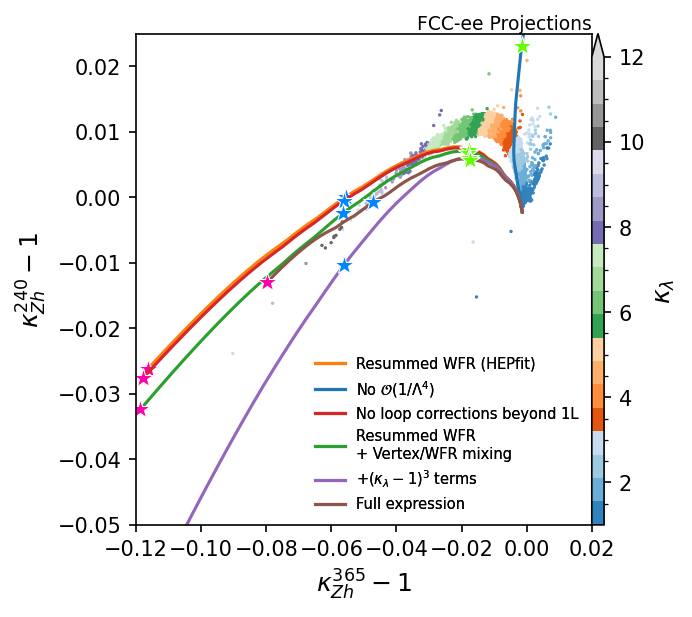

In [ ]:
n_curves = 6
legend_locs = [None, None, None, None, None, "lower right",]
legend_fontsizes = [7.0 for _ in range(n_curves)]
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    max_n_markers=3,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
)
ax.set_xlim(-0.12, +0.02)
ax.set_ylim(-0.050, +0.025)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_all_WCs_markers_zoom.pdf")


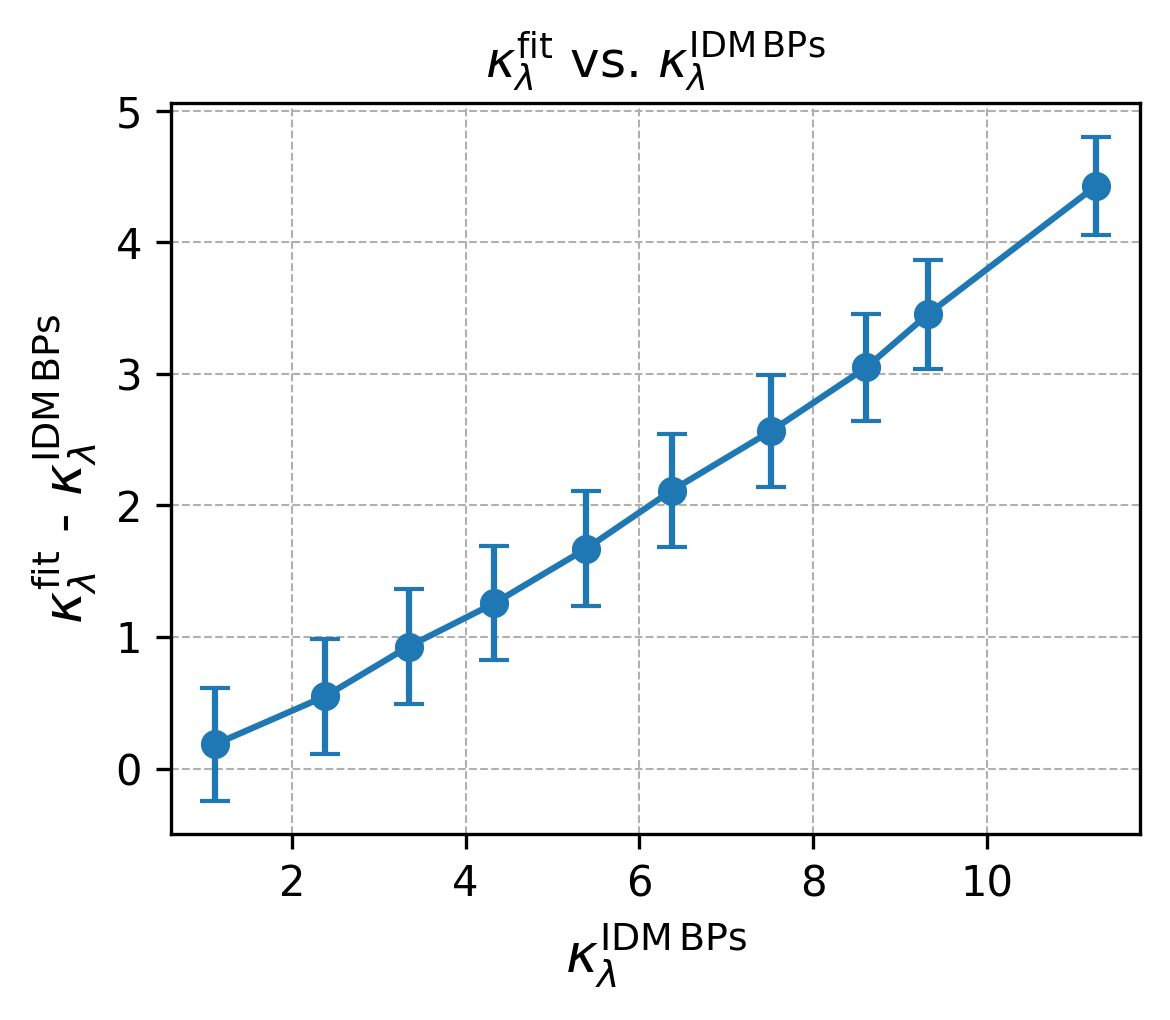

In [ ]:
klam_BPs = np.array([BP["lam"] for BP in bp_kappas])
klam_BPs = np.array([klam_BPs[i] for i in BP_indices_for_curve])
# k_ZH_240_BPs = [BP["ZZ_240_with_WFR_ZZh1L_hextlegonly"] for BP in bp_kappas]
# k_ZH_365_BPs = [BP["ZZ_365_with_WFR_ZZh1L_hextlegonly"] for BP in bp_kappas]

klam_fits = []
klam_fits_errors = []
input_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Fits_HLLHC_FCCee/different_BPs/comparison_plots/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long"
with open(f"{input_dir}/klam_results.txt", 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if i == 0:  # Skip header line
            continue

        BP, klam, klam_error = line.split(",")
        klam_fits.append(float(klam))
        klam_fits_errors.append(float(klam_error))

klam_fits = np.array(klam_fits[::2])
klam_fits_errors = np.array(klam_fits_errors[::2])

spline_degree = 1  # Linear interpolation
klam_interpolator = make_interp_spline(klam_BPs, klam_fits, k=spline_degree)

# klam_curve = np.linspace(-32, 0, 50)

delta_klam = klam_fits - klam_BPs
color = "tab:blue"
plt.subplots(figsize=(4.0, 3.5), dpi=300)
plt.plot(klam_BPs, delta_klam, color=color)
plt.errorbar(klam_BPs, delta_klam, yerr=klam_fits_errors, fmt='o', capsize=3.5, color=color)
    
plt.xlabel(r"$\kappa_\lambda^{\mathrm{IDM\/BPs}}$", fontsize=13)
plt.ylabel(r"$\kappa_\lambda^{\mathrm{fit}}$ - $\kappa_\lambda^{\mathrm{IDM\/BPs}}$", fontsize=13)
plt.title(r"$\kappa_\lambda^{\mathrm{fit}}$ vs. $\kappa_\lambda^{\mathrm{IDM\/BPs}}$")
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"k_ZH_240_365_uncertainties_klam_fit_vs_IDM.pdf")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


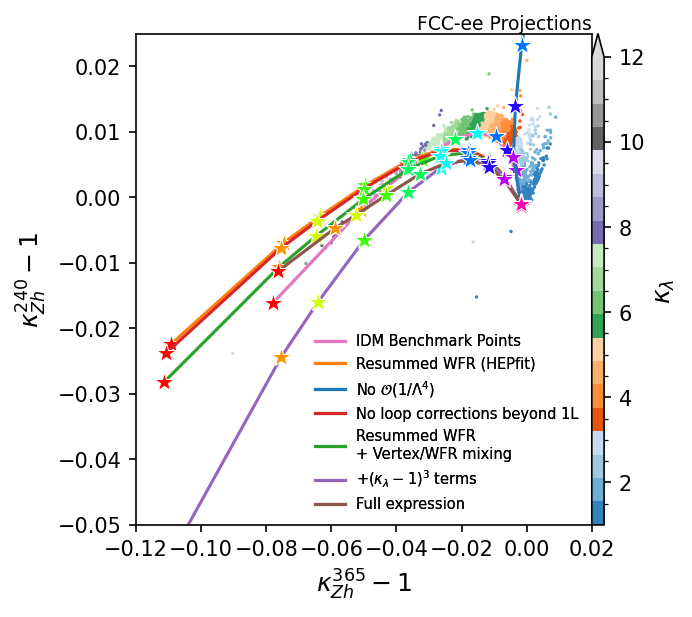

In [ ]:
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/all_WCs/comparison_plots"
flags = ["", "_noLoopH3d6Quad", "_LoopHd6NoSubleading", "_LoopH3d6Quad_C1term", "_LoopH3d6Cubi", "_LoopH3d6Full"]
for flag in flags:
    with open(f"{results_directory}/k_ZH_240_365_predictions_BPs_{flag}.txt", 'r') as input_file:
        with open(f"{results_directory}/k_ZH_240_365_predictions_BPs_{flag}_even.txt", 'w') as output_file:
            lines = input_file.readlines()
            for idx, line in enumerate(lines):
                if idx % 4 == 0 or idx % 4 == 1:
                    output_file.write(line)


k_ZH_240_365_predictions_file_names_all_WCs = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs__even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Quad_C1term_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Cubi_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Full_even.txt",
]
n_curves = len(k_ZH_240_365_predictions_file_names_all_WCs)

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = [plot_points_with_WFR[i] for i in BP_indices_for_curve]

legend_locs = [None, None, None, None, None, None, "lower right",]
legend_cols = [1 for _ in range(n_curves)]
legend_fontsizes = [7.0 for _ in range(n_curves)]
markers = ["*" for _ in range(n_curves)]
markersizes = [10 for _ in range(n_curves)]
color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'IDM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "IDM",
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
    None,
    None,
    None,
    None,
]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(-0.12, +0.02)
ax.set_ylim(-0.050, +0.025)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_uncertainty_all_WCs_with_IDM_WFR_BPs_zoom.pdf")


Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


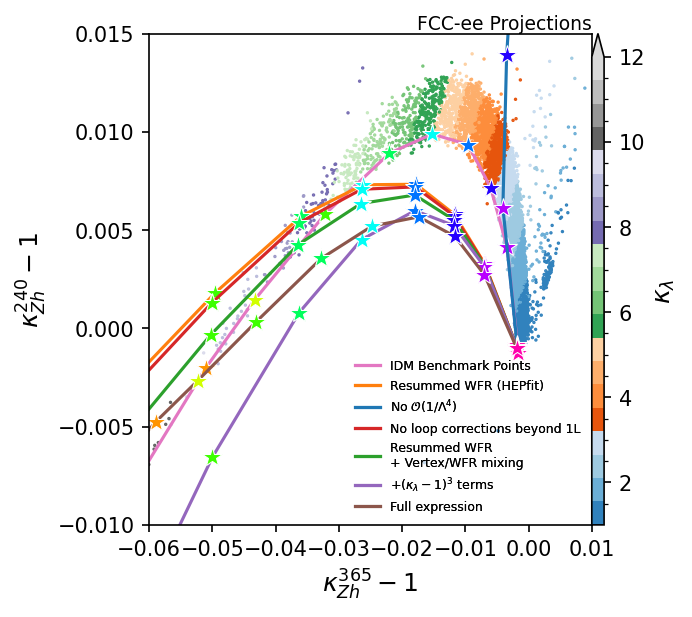

In [ ]:
n_curves = 7
legend_locs = [None, None, None, None, None, None, "lower right",]
legend_fontsizes = [ 6.0 for _ in range(n_curves) ]
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(-0.06, +0.01)
ax.set_ylim(-0.010, +0.015)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_uncertainty_all_WCs_with_IDM_WFR_BPs_zoom2.pdf")

Processing file: /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots/k_ZH_240_365_predictions_BPs__even.txt
[0.9990554595048612, 1.0032882084333903, 1.0057934192133393, 1.0073297694563659, 1.0073045106360168, 1.0057118064899806, 1.0018205093246724, 0.9971125167833784, 0.9930381690598447, 0.9775456204878801]
Processing file: /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad_even.txt
[0.9991270679307822, 1.0061392522007802, 1.013891481867508, 1.0231766600502017, 1.0348053419477665, 1.0473685043589105, 1.0628417365640555, 1.080663542671499, 1.0944510574066586, 1.133515893777663]
Processing file: /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading_even.txt
[0.9990541812335461, 1.0032615651237649, 1.005722849852799, 1.007195480366

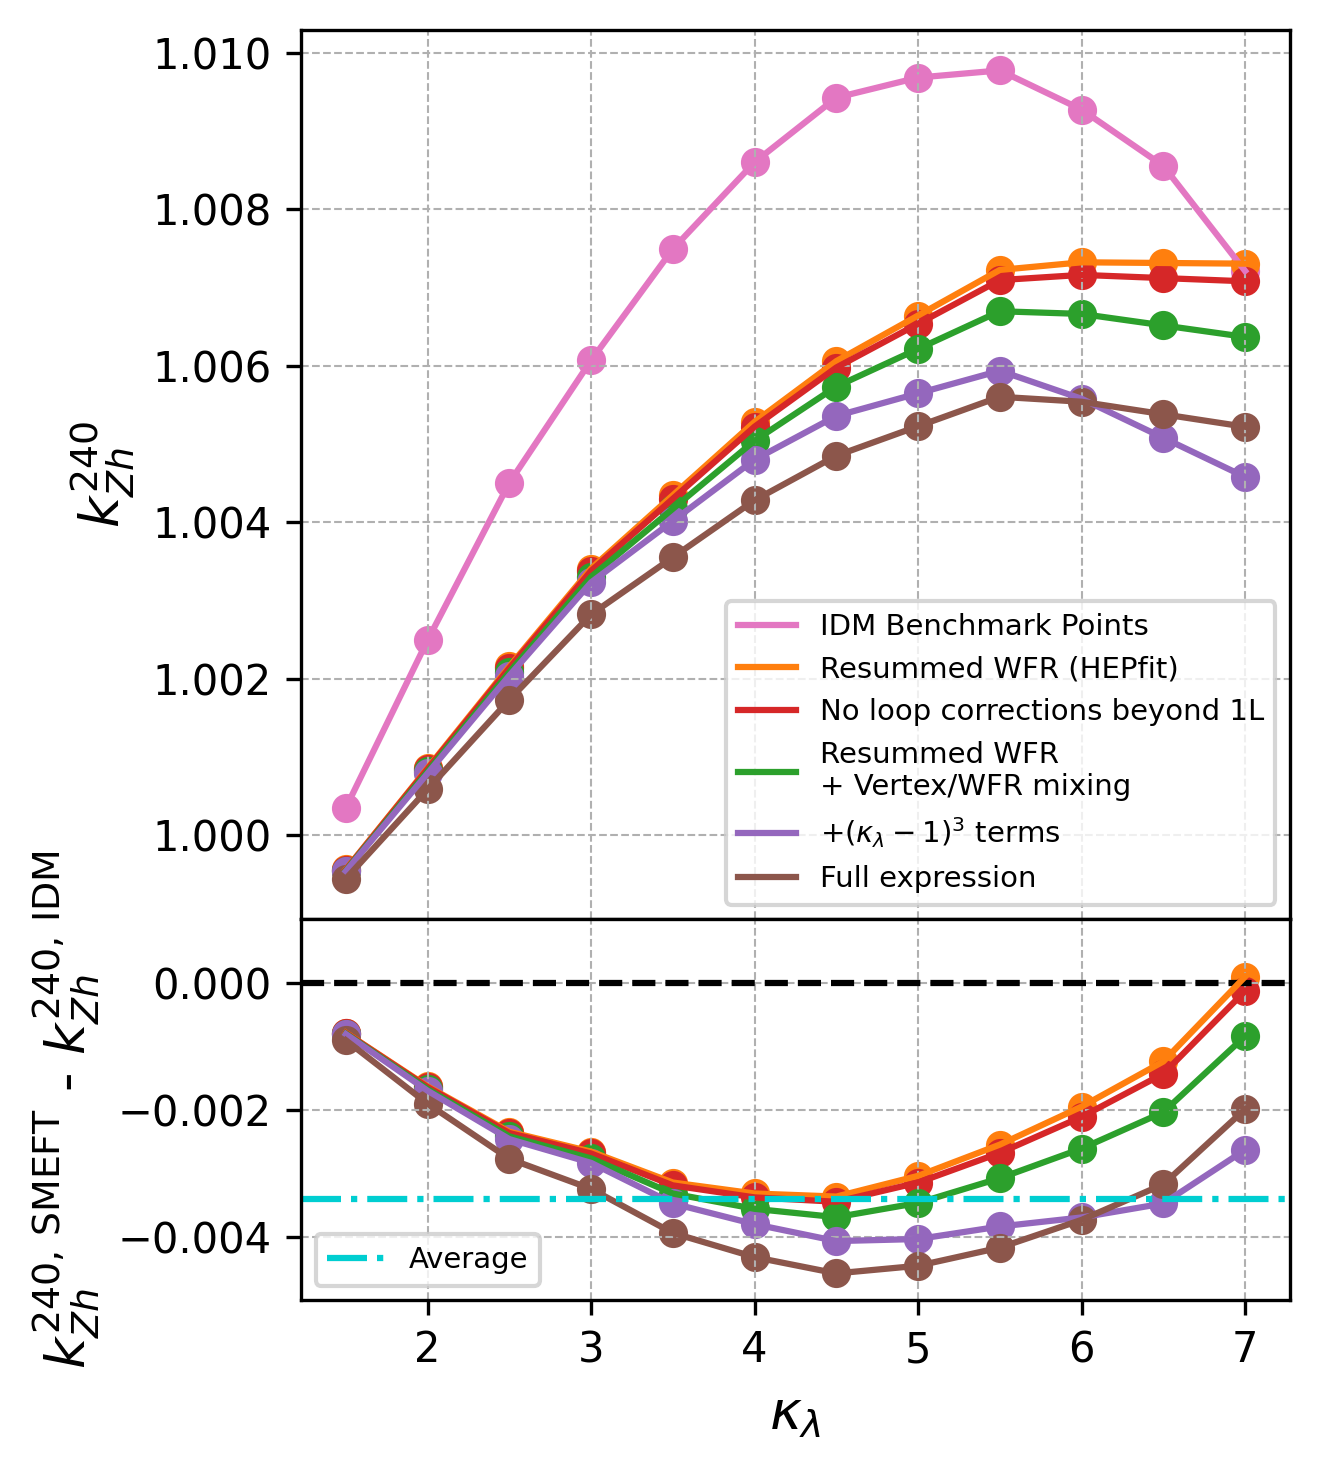

In [ ]:
spline_degree = 1  # Linear interpolation
interpolators = {}
# klam_points = np.array([1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
klam_points = np.linspace(1.5, 7.0, 12)

interpolations = {}
for flag in flags:
    interpolators[flag] = {}
    interpolations[flag] = {}
    file_name = f"{results_directory}/k_ZH_240_365_predictions_BPs_{flag}_even.txt"
    print(f"Processing file: {file_name}")
    k_ZH_240_values = []
    k_ZH_365_values = []
    with open(file_name, "r") as self_consistent_results_file:
        lines = self_consistent_results_file.readlines()
        for n, line in enumerate(lines):
            columns = line.split()

            if columns[-2].startswith("eeZH_FCCee240"):
                k_ZH_240_values.append(np.sqrt(float(columns[-1])))
            elif columns[-2].startswith("eeZH_FCCee365"):
                k_ZH_365_values.append(np.sqrt(float(columns[-1])))
        print(k_ZH_240_values)
    interpolators[flag]["k_ZH_240"] = make_interp_spline(klam_fits, k_ZH_240_values, k=spline_degree)
    interpolators[flag]["k_ZH_365"] = make_interp_spline(klam_fits, k_ZH_365_values, k=spline_degree)

    interpolations[flag]["k_ZH_240"] = interpolators[flag]["k_ZH_240"](klam_points)
    interpolations[flag]["k_ZH_365"] = interpolators[flag]["k_ZH_365"](klam_points)

k_ZH_240_BPs = [BP["ZZ_240_with_WFR"] for BP in bp_kappas]
k_ZH_365_BPs = [BP["ZZ_365_with_WFR"] for BP in bp_kappas]
k_ZH_240_BPs = np.array([k_ZH_240_BPs[i] for i in BP_indices_for_curve])
k_ZH_365_BPs = np.array([k_ZH_365_BPs[i] for i in BP_indices_for_curve])
IDM_interpolator_k_ZH_240 = make_interp_spline(klam_BPs, k_ZH_240_BPs, k=spline_degree)
IDM_interpolator_k_ZH_365 = make_interp_spline(klam_BPs, k_ZH_365_BPs, k=spline_degree)
IDM_interpolation_k_ZH_240 = IDM_interpolator_k_ZH_240(klam_points)
IDM_interpolation_k_ZH_365 = IDM_interpolator_k_ZH_365(klam_points)

# fig, ax = plt.subplots(figsize=(4.0, 3.5), dpi=300)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(4.5, 5), height_ratios=[0.7, 0.3], dpi=300, gridspec_kw=dict(hspace=0.))

flag_colors = ["tab:orange", "tab:blue", "tab:red", "tab:green", "tab:purple", "tab:brown"]
flag_labels = [
    # r'IDM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.plot(klam_points, IDM_interpolation_k_ZH_240, label=r'IDM Benchmark Points', color="tab:pink")
ax1.scatter(klam_points, IDM_interpolation_k_ZH_240, color="tab:pink")
for idx, (flag, color, label) in enumerate(zip(flags, flag_colors, flag_labels)):
    if flag == "_noLoopH3d6Quad":
        continue
    ax1.plot(klam_points, interpolations[flag]["k_ZH_240"], label=label, color=color)
    ax1.scatter(klam_points, interpolations[flag]["k_ZH_240"], color=color)

    ax2.plot(klam_points, interpolations[flag]["k_ZH_240"] - IDM_interpolation_k_ZH_240, color=color)
    ax2.scatter(klam_points, interpolations[flag]["k_ZH_240"] - IDM_interpolation_k_ZH_240, color=color)
    # plt.plot(klam_points, interpolations[flag]["k_ZH_365"], label=f"k_ZH_365 {flag}", color="tab:orange")

ax2.set_xlabel(r"$\kappa_\lambda$", fontsize=13)
ax1.set_ylabel(r"$k_{Zh}^{240}$", fontsize=13)
ax2.set_ylabel(r"$k_{Zh}^{240,\/\mathrm{SMEFT}}$ - $k_{Zh}^{240,\/\mathrm{IDM}}$", fontsize=13)
# plt.title(r"$k_{Zh}^{240}$ vs. $\kappa_\lambda$ for different flags")
ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax2.grid(which='both', linestyle='--', linewidth=0.5)
ax1.legend(fontsize=7.0, loc='lower right')
ax2.set_ylim(-0.005, 0.001)

# Obtaining uncertainty estimate:
err_estimate = []
for idx, klam in enumerate(klam_points[:-2]):
    flags_for_error = [flag for flag in flags if flag != "_noLoopH3d6Quad" ]
    diffs = [interpolations[flag]["k_ZH_240"][idx] - IDM_interpolation_k_ZH_240[idx] for flag in flags_for_error]
    err_estimate.append( np.max( np.abs(diffs) ) )
print(f"Maximum errors: {err_estimate}")
k_Zh_240_err = np.mean(err_estimate)
print(f"k_Zh_240 uncertainty estimate: {k_Zh_240_err}")
print(f"sigma_Zh_240 uncertainty estimate: {2 * (np.mean(IDM_interpolation_k_ZH_240)) * k_Zh_240_err}")
ax2.axhline(-k_Zh_240_err, color='darkturquoise', linestyle='-.', linewidth=1.5, label="Average")
ax2.legend(fontsize=7.0, loc='best')

plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_k_ZH_240_vs_kappa_lambda_all_WCs.pdf")

Maximum errors: [0.000334002745037143, 0.0011927408238858739, 0.001905300290698575, 0.0021423301483479706, 0.0024603081046734587, 0.002474093435301694, 0.002432594834000601, 0.002085621167978946, 0.0015745402253083407, 0.0009166531117026366]
k_Zh_365 uncertainty estimate: 0.001751818488693524
sigma_Zh_365 uncertainty estimate: 0.0034632124670086065


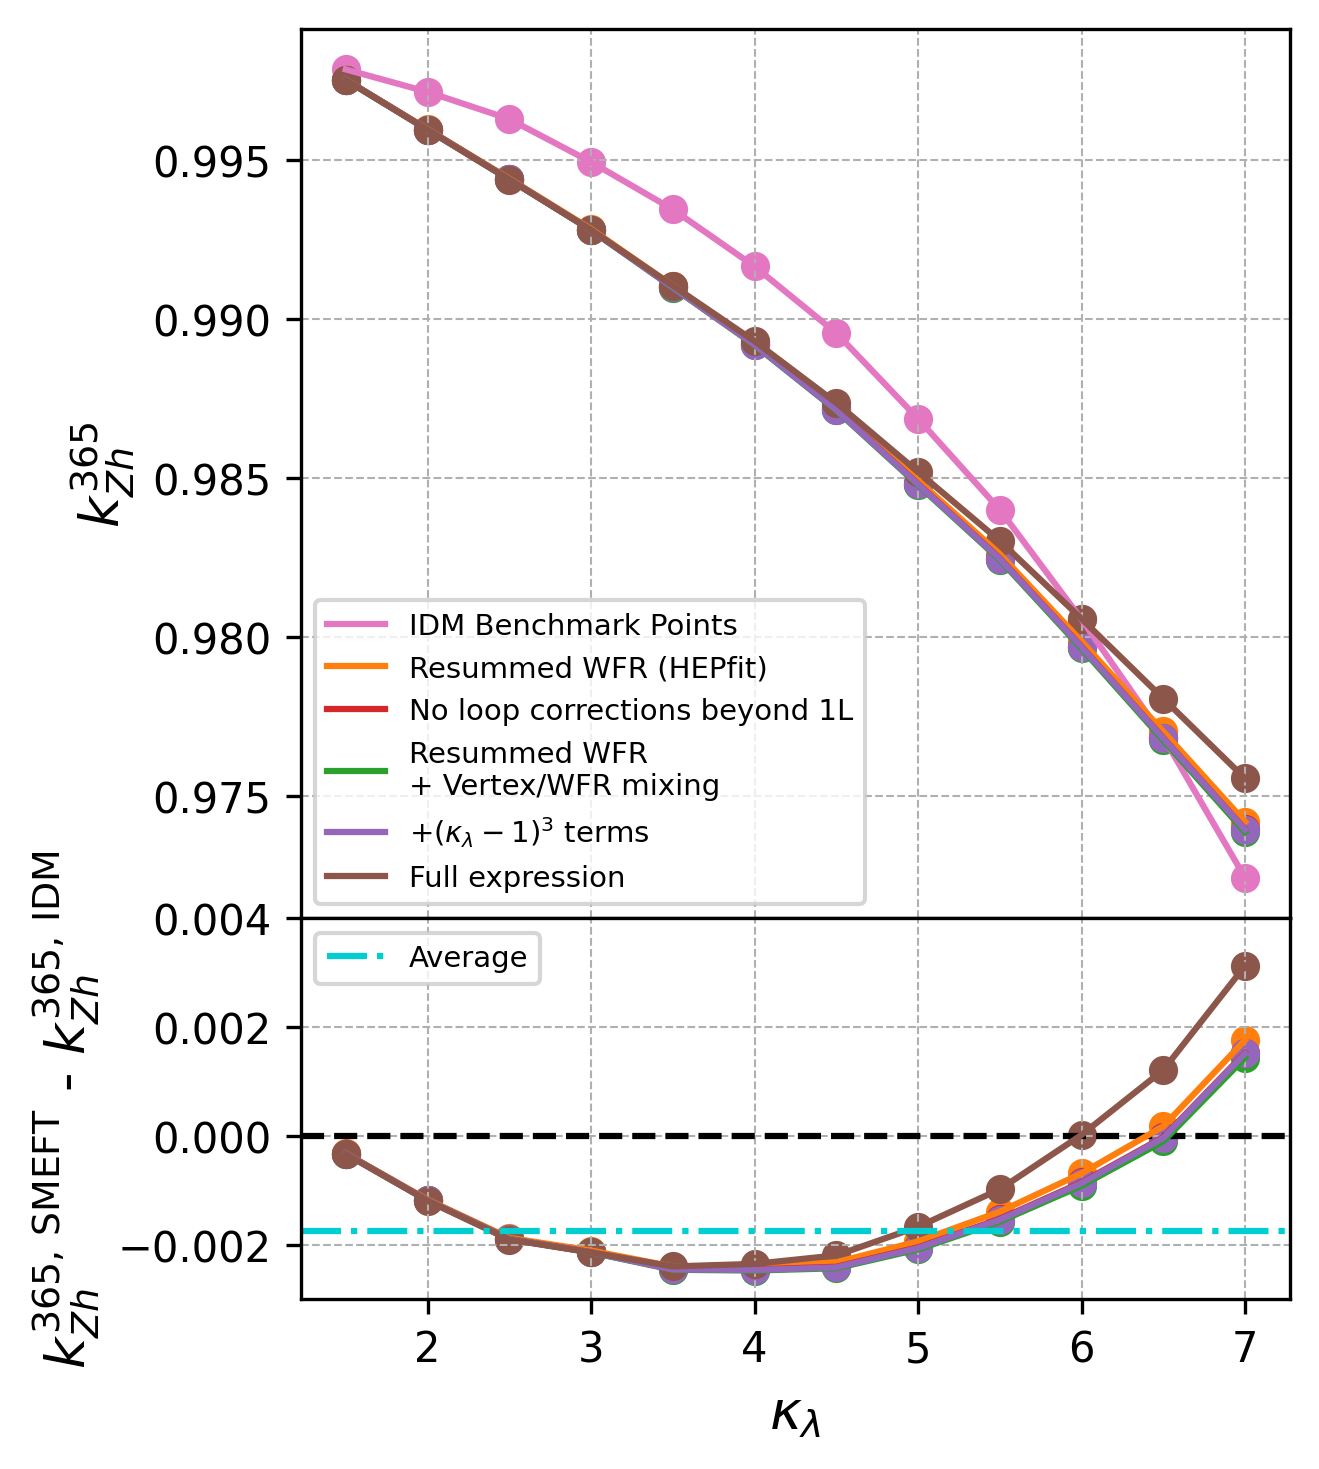

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(4.5, 5), height_ratios=[0.7, 0.3], dpi=300, gridspec_kw=dict(hspace=0.))

ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.plot(klam_points, IDM_interpolation_k_ZH_365, label=r'IDM Benchmark Points', color="tab:pink")
ax1.scatter(klam_points, IDM_interpolation_k_ZH_365, color="tab:pink")
for idx, (flag, color, label) in enumerate(zip(flags, flag_colors, flag_labels)):
    if flag == "_noLoopH3d6Quad":
        continue
    ax1.plot(klam_points, interpolations[flag]["k_ZH_365"], label=label, color=color)
    ax1.scatter(klam_points, interpolations[flag]["k_ZH_365"], color=color)

    ax2.plot(klam_points, interpolations[flag]["k_ZH_365"] - IDM_interpolation_k_ZH_365, color=color)
    ax2.scatter(klam_points, interpolations[flag]["k_ZH_365"] - IDM_interpolation_k_ZH_365, color=color)
    # plt.plot(klam_points, interpolations[flag]["k_ZH_365"], label=f"k_ZH_365 {flag}", color="tab:orange")

ax2.set_xlabel(r"$\kappa_\lambda$", fontsize=13)
ax1.set_ylabel(r"$k_{Zh}^{365}$", fontsize=13)
ax2.set_ylabel(r"$k_{Zh}^{365,\/\mathrm{SMEFT}}$ - $k_{Zh}^{365,\/\mathrm{IDM}}$", fontsize=13)
# plt.title(r"$k_{Zh}^{365}$ vs. $\kappa_\lambda$ for different flags")
ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax2.grid(which='both', linestyle='--', linewidth=0.5)
ax1.legend(fontsize=7.0, loc='lower left')
ax2.set_ylim(-0.003, 0.004)

# Obtaining uncertainty estimate:
err_estimate = []
for idx, klam in enumerate(klam_points[:-2]):
    flags_for_error = [flag for flag in flags if flag != "_noLoopH3d6Quad" ]
    diffs = [interpolations[flag]["k_ZH_365"][idx] - IDM_interpolation_k_ZH_365[idx] for flag in flags_for_error]
    err_estimate.append( np.max( np.abs(diffs) ) )
print(f"Maximum errors: {err_estimate}")
k_Zh_365_err = np.mean(err_estimate)
print(f"k_Zh_365 uncertainty estimate: {k_Zh_365_err}")
print(f"sigma_Zh_365 uncertainty estimate: {2 * (np.mean(IDM_interpolation_k_ZH_365)) * k_Zh_365_err}")
ax2.axhline(-k_Zh_365_err, color='darkturquoise', linestyle='-.', linewidth=1.5, label="Average")
ax2.legend(fontsize=7.0, loc='best')

plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_k_ZH_365_vs_kappa_lambda_all_WCs.pdf")


## Finding BP with $\kappa_\lambda \approx 1$

In [ ]:
from utils.common_utils import find_benchmark_lambda1

BR_constraints=0.05
data_file="data/IDM/allIDMpoints_2025-01-14"
df = pd.read_csv(data_file + ".csv")

df = df.replace("", np.nan)
df = df.dropna()
old_df_indices = df.index.to_numpy()
df = df.reset_index(drop=True)
n_pts = df.shape[0]

kappas, EWPOs, model_pars = read_Z2SSM_file(df)

output_dir = "./scan_output/IDM_scan_output"
subprocess.run(["mkdir", "-p", output_dir])

BP_filename = f"{output_dir}/Benchmark_Points_lambda1.txt"
BR_constraint=0.05

BP_Name = "BP_lambda1"

bp_klam1_kappas, bp_klam1_EWPOs, bp_klam1_model_pars, _ = find_benchmark_lambda1(
    n_pts=n_pts,
    kappas=kappas,
    EWPOs=EWPOs,
    model_pars=model_pars,
    old_df_indices=old_df_indices,
    BP_Name=BP_Name,
    BR_constraints=BR_constraints,
)
print(bp_klam1_kappas)


elif BP == "BP_lambda1":
    kappas['uu'] = 0.9984178113049657
    kappas['dd'] = 0.9984178113049657
    kappas['ss'] = 0.9984178113049657
    kappas['cc'] = 0.9984178113049657
    kappas['bb'] = 0.9984178113049657
    kappas['tt'] = 0.9984178113049657
    kappas['ee'] = 0.9984178113049657
    kappas['mumu'] = 0.9984178113049657
    kappas['tautau'] = 0.9984178113049657
    kappas['ZZ_0'] = 0.9991982973881574
    kappas['ZZ_240'] = 0.9998186516447237
    kappas['ZZ_365'] = 0.999375887226692
    kappas['ZZ_500'] = 0.9993603116685574
    kappas['ZZ_550'] = 0.9994021868768549
    kappas['ZZ'] = 0.9983808715093025
    kappas['WW'] = 0.9983808715093025
    kappas['lam'] = 1.1000242642433875
    kappas['gamgam'] = 0.9919985602913337
    kappas['Zgam'] = 0.9970379541928285
    kappas['ZZ_0_with_WFR'] = 0.9990362027510766
    kappas['ZZ_240_with_WFR'] = 0.9996569626228905
    kappas['ZZ_365_with_WFR'] = 0.9992139481033878
    kappas['ZZ_500_with_WFR'] = 0.9991983601708374
    kappas['ZZ_550_w

## Final plot for the 2-page document

In [ ]:
# Add BP_lambda1 to the set of BPs for plots
BP_Names += ["BP_lambda1"]
bp_kappas += [bp_klam1_kappas]
bp_EWPOs += [bp_klam1_EWPOs]
bp_model_pars += [bp_klam1_model_pars]
print(bp_kappas)

[{'uu': 0.9818547810617284, 'dd': 0.9818547810617284, 'ss': 0.9818547810617284, 'cc': 0.9818547810617284, 'bb': 0.9818547810617284, 'tt': 0.9818547810617284, 'ee': 0.9818547810617284, 'mumu': 0.9818547810617284, 'tautau': 0.9818547810617284, 'ZZ_0': 1.007141704579298, 'ZZ_240': 1.0237693288776533, 'ZZ_365': 1.0074536101415776, 'ZZ_500': 1.0026988104523176, 'ZZ_550': 1.0021232678597285, 'ZZ': 0.9899392240917029, 'WW': 0.9899392240917029, 'lam': 4.038636858901748, 'gamgam': 0.9514322699531608, 'Zgam': 0.9820015140523058, 'ZZ_0_with_WFR': 0.9953498248226368, 'ZZ_240_with_WFR': 1.0119172507528293, 'ZZ_365_with_WFR': 0.9956631382646509, 'ZZ_500_with_WFR': 0.990876120168658, 'ZZ_550_with_WFR': 0.9902951077003839, 'ZZ_0_with_WFR_no_BSM': 1.000617382762773, 'ZZ_240_with_WFR_no_BSM': 1.015950662913649, 'ZZ_365_with_WFR_no_BSM': 0.9981502437103232, 'ZZ_500_with_WFR_no_BSM': 0.9906558146426329, 'ZZ_550_with_WFR_no_BSM': 0.9887425788229198, 'ZZ_0_with_WFR_ZZh1L_hextlegonly': 0.9823159923418117, 'Z

[{'uu': 0.9984178113049657, 'dd': 0.9984178113049657, 'ss': 0.9984178113049657, 'cc': 0.9984178113049657, 'bb': 0.9984178113049657, 'tt': 0.9984178113049657, 'ee': 0.9984178113049657, 'mumu': 0.9984178113049657, 'tautau': 0.9984178113049657, 'ZZ_0': 0.9991982973881574, 'ZZ_240': 0.9998186516447237, 'ZZ_365': 0.999375887226692, 'ZZ_500': 0.9993603116685574, 'ZZ_550': 0.9994021868768549, 'ZZ': 0.9983808715093025, 'WW': 0.9983808715093025, 'lam': 1.1000242642433875, 'gamgam': 0.9919985602913337, 'Zgam': 0.9970379541928285, 'ZZ_0_with_WFR': 0.9990362027510766, 'ZZ_240_with_WFR': 0.9996569626228905, 'ZZ_365_with_WFR': 0.9992139481033878, 'ZZ_500_with_WFR': 0.9991983601708374, 'ZZ_550_with_WFR': 0.9992402680960598, 'ZZ_0_with_WFR_no_BSM': 1.000246471444266, 'ZZ_240_with_WFR_no_BSM': 1.000755130849711, 'ZZ_365_with_WFR_no_BSM': 1.000165326196393, 'ZZ_500_with_WFR_no_BSM': 0.9999200197146211, 'ZZ_550_with_WFR_no_BSM': 0.9998576826197325, 'ZZ_0_with_WFR_ZZh1L_hextlegonly': 0.9986634199001364, '

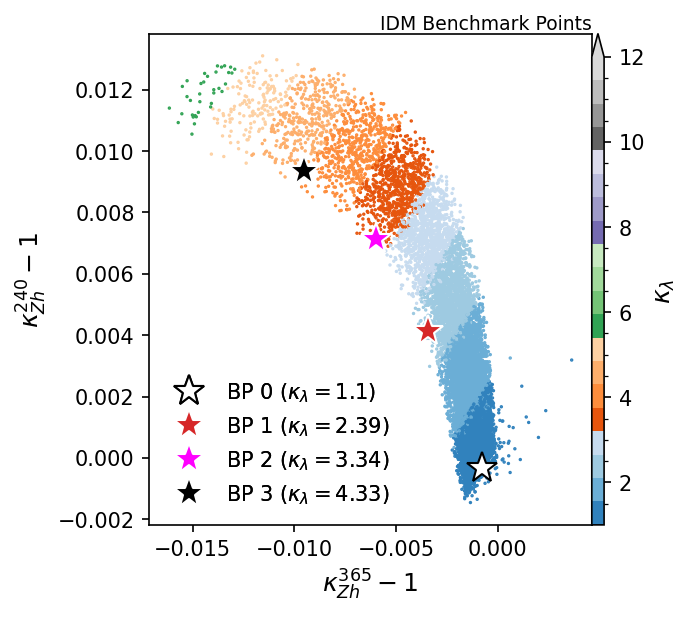

In [ ]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
BR_constraints = 0.05
BPs_plot_final = ["BP_lambda1", "BPB_2", "BPB_4", "BPB_6", ]

BP_Names_legend_plot_final = [rf"BP {i} ($\kappa_\lambda=${bp_kappas[BP_Names.index(BP)]['lam']:.3g})"  for i, BP in enumerate(BPs_plot_final)]
bp_kappas_plot_final = [bp_kappas[BP_Names.index(BP)] for BP in BPs_plot_final]
print(bp_kappas_plot_final)
plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"], 
     label ) for BP, label in zip(bp_kappas_plot_final, BP_Names_legend_plot_final)
]

plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                       BR_constraints=BR_constraints,
                       max_num_bulk_points=max_num_bulk_points,
                       plot_points=plot_points_with_WFR,
                      #  point_colors="lambdas",
                       point_colors=["white", "tab:red", "fuchsia", "k"],
                       point_leg_columns=1,
                       point_leg_size=10,
                       legend_loc="lower left",
                      #  point_marker_size=[13, 10, 10],
                       point_marker_size=[15, 15, 15, 15],
                      #  point_markers=["*", "o", "^"],
                       point_markers=["*", "*", "*", "*"],
                       no_model_text=True,
                       upper_right_text="IDM Benchmark Points",
                    #    plot_name_suffix="_final_2pager",
                       markeredgewidth=[1, 1, 1, 1],
                       markeredgecolor=["black", "white", "white", "white"],
                       func_read_file_args={
                           'data_with_WFR': True,
                           'data_with_WFR_no_BSM_vertex': False,
                           'data_with_WFR_ZZh1L_hextlegonly': False
                       }
                )
plot_name= f"IDM_BPs_240_vs_365_{BR_constraints:0.3g}_SM_constraints_BPs_final"
plot_name_suffix="_with_WFR"
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14
Number of points satisfying the 5% SM constraint on the single higgs couplings: 14014 / 14048


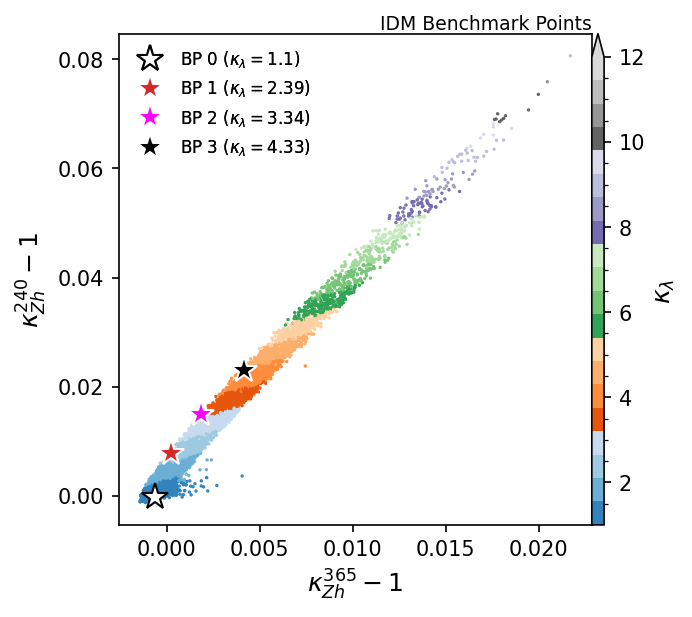

In [ ]:
# Old, without Higgs WFR 
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas_plot_final, BP_Names_legend_plot_final)]

plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                       BR_constraints=BR_constraints,
                       max_num_bulk_points=max_num_bulk_points,
                       plot_points=plot_points,
                       point_colors=["white", "tab:red", "fuchsia", "k"],
                       point_leg_columns=1,
                       point_leg_size=8,
                       point_marker_size=[13, 13, 13, 13],
                       point_markers=["*", "*", "*", "*"],
                       no_model_text=True,
                       upper_right_text="IDM Benchmark Points",
                       markeredgewidth=[1, 1, 1, 1],
                       markeredgecolor=["black", "white", "white", "white"],
                )
plot_name= f"IDM_BPs_240_vs_365_{BR_constraints:0.3g}_SM_constraints_BPs_final"
plot_name_suffix=""
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

### Generate table with model parameters

In [ ]:
model_pars_names = [
    r"$\mu_{S}\;[\si{\GeV}]$",
    r"$\lambda_{S}$",
    r"$\lambda_{SH}$",
    r"$m_S\;[\si{\GeV}]$",
]

model_pars = [
    "muS",
    "lamS", 
    "lamSH", 
    "mS", 
]

first_line = ""
for par in model_pars_names:
    first_line = first_line + " & " + par
first_line = first_line + r" \\ \hline\hline"
print(first_line)

for i, BP in enumerate(BPs_plot_final):

    line = f"BP {i}"
    for par in model_pars:
        # if par == "mu2sq":
        #     # line = line + f" & {bp_model_pars[BP_Names.index(BP)][par]:.6g}"
        #     line = line + rf" & \num[exponent-mode = scientific]{{{bp_model_pars[BP_Names.index(BP)][par]:.4}}}"
        # else:
        #     line = line + f" & ${bp_model_pars[BP_Names.index(BP)][par]:.4g}$"
        #     # line = line + rf" & \SI{{{bp_model_pars[BP_Names.index(BP)][par]}}}"
        line = line + f" & ${bp_model_pars[BP_Names.index(BP)][par]:.4g}$"
    line = line + r" \\ \hline"
    print(line)

 & $\mu_2^2\;[\si{\GeV^2}]$ & $\lambda_1\;[\si{\GeV}]$ & $\lambda_2\;[\si{\GeV}]$ & $\lambda_3\;[\si{\GeV}]$ & $\lambda_4\;[\si{\GeV}]$ & $\lambda_5\;[\si{\GeV}]$ & $m_H\;[\si{\GeV}]$ & $m_A\;[\si{\GeV}]$ & $m_{H^{\pm}}\;[\si{\GeV}]$ \\ \hline\hline
BP 0 & \num[exponent-mode = scientific]{1.178e+06} & $0.2581$ & $6.213$ & $7.169$ & $-4.512$ & $-3.143$ & $1079$ & $1164$ & $1181$ \\ \hline
BP 1 & \num[exponent-mode = scientific]{3.666e+05} & $0.2581$ & $3.084$ & $11.46$ & $-5.68$ & $-5.109$ & $622.2$ & $834.8$ & $845.1$ \\ \hline
BP 2 & \num[exponent-mode = scientific]{3.922e+05} & $0.2581$ & $10.06$ & $14.19$ & $-6.974$ & $-6.407$ & $645.6$ & $897.3$ & $906.8$ \\ \hline
BP 3 & \num[exponent-mode = scientific]{3.432e+05} & $0.2581$ & $8.985$ & $15.83$ & $-7.704$ & $-7.4$ & $604.3$ & $902.1$ & $907.2$ \\ \hline


## Consistency checks: checking numerical values for $\delta Z_{h}$ and C1

Processing data file: data/IDM/allIDMpoints_2025-01-14


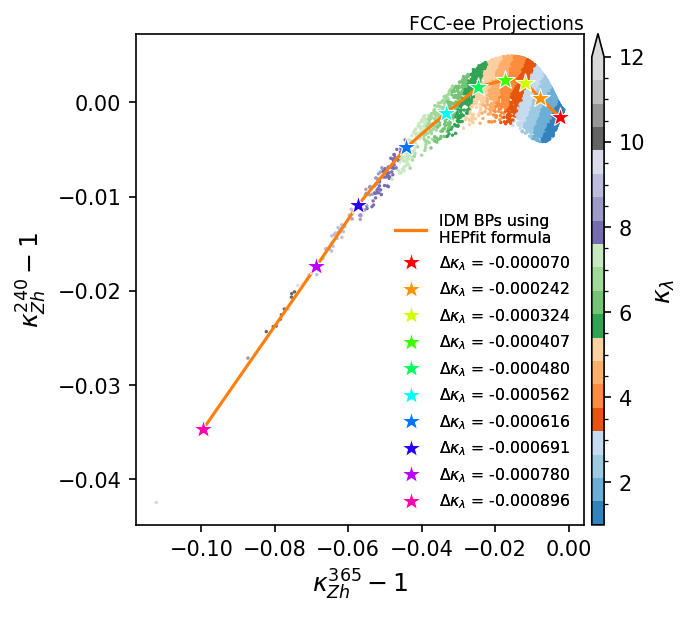

In [ ]:
from utils.common_utils import analytical_formula_CH_CHBox_general_C1

def analytical_formula_Johannes_C1_values(mu_240, mu_365):
    return analytical_formula_CH_CHBox_general_C1(mu_240, mu_365, C1_values=c1_johannes)

plot_points_analytical_formula = []
for BP, label in zip(bp_kappas, BP_Names_legend):
    k_ZH_365 = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1))
    k_ZH_240 = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1))
    CH, CHBox, lmbd = analytical_formula_Johannes_C1_values(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)

    plot_points_analytical_formula.append((k_ZH_365-1, k_ZH_240-1, BP["lam"]-lmbd, label))

plot_points_analytical_formula = [plot_points_analytical_formula[i] for i in BP_indices_for_curve]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'smeft_formula_Johannes_C1_values': True,
                        }
                )

data_sets = [plot_points_analytical_formula,]
legend_locs = ['lower right',]
legend_fontsizes = [6.0,]
markers = ["*", ]
markersizes = [10, ]
curves_matching_lambdas = ["IDM_HEPfit"]
file_names_matching_lambdas = [None,]
color_lines = ["tab:orange",]
label_lines = ['IDM BPs using\nHEPfit formula',]
legend_cols = [1,]
legend_fontsizes = [7.5,]
klam_in_point_labels = r"$\Delta \kappa_{\lambda}$"

plot_name_suffix = ""
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_Johannes_C1_values_matching_lambdas_dkala_analytical.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


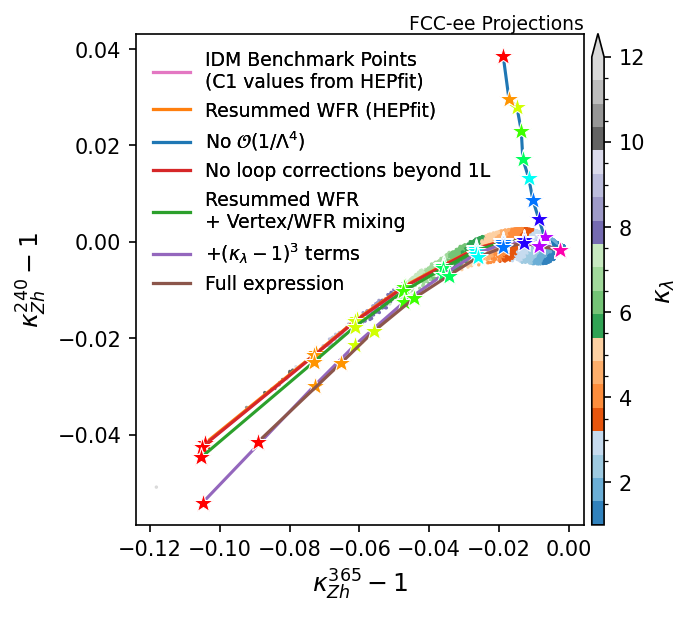

In [ ]:
########################################################
### data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values ###
########################################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values"] - 1,
     BP["ZZ_240_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = [plot_points_with_WFR[i] for i in BP_indices_for_curve]

color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'IDM Benchmark Points'+'\n'+'(C1 values from HEPfit)',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "IDM",
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
    None,
    None,
    None,
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs_.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Full.txt",
]
n_curves = len(k_ZH_240_365_predictions_file_names)
legend_locs = [None, None, None, None, None, None, "upper left",]
legend_cols = [1 for _ in range(n_curves)]
legend_fontsizes = [9.0 for _ in range(n_curves)]
markers = ["*" for _ in range(n_curves)]
markersizes = [10 for _ in range(n_curves)]
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
plot_name = "Uncertainties_final_plot"
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


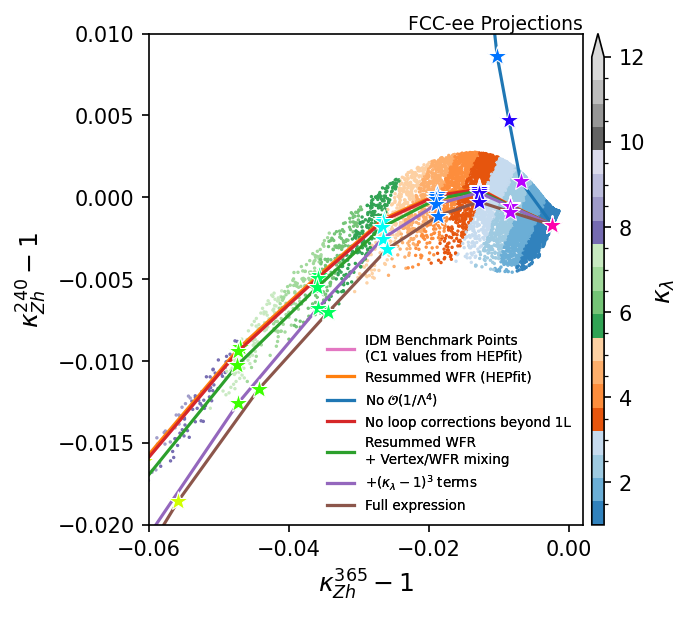

In [ ]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )
legend_locs = [None, None, None, None, None, None, 'lower right',]
legend_fontsizes = [6.5 for _ in range(n_curves)]
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
plt.show()
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves_zoom.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


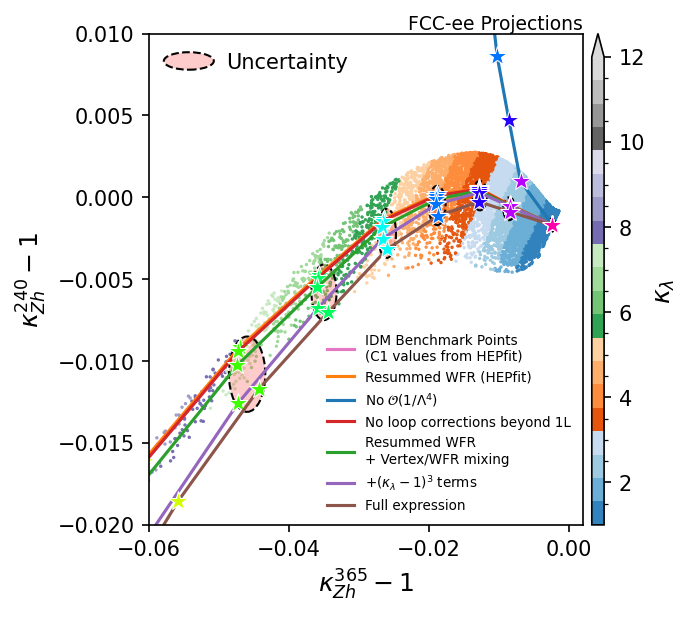

In [ ]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        max_num_bulk_points=max_num_bulk_points,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )       

plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)

xs     = [-2.4e-3, -0.0085, -0.0127, -0.0188,  -0.026, -0.035, -0.0460, ]
ys     = [-1.7e-3, -7.0e-4,  0.0001,  -0.0005, -0.0022, -0.0058, -0.0108, ]
err_xs = [0.5e-3,   0.85e-3,  1.0e-3,  1.2e-3,  1.3e-3, 1.8e-3, 2.6e-3, ]
err_ys = [4.0e-4,   0.7e-3,  0.9e-3,  1.2e-3,  1.5e-3, 1.7e-3, 2.3e-3, ] 
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+f"_HEPfit_C1_values_curves_zoom_ellipses.pdf")

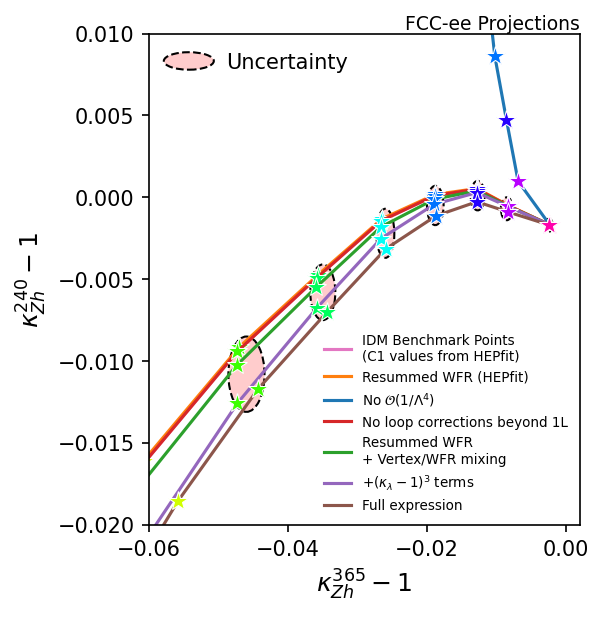

In [ ]:
fig, ax = plt.subplots(
    figsize=(3.91, 4.0),
    constrained_layout=True)

ax.set_xlabel(r'$\kappa_{Zh}^{365} - 1$')
ax.set_ylabel(r'$\kappa_{Zh}^{240} - 1$')

text_collider = "FCC-ee Projections"
ax.text(
    1,
    1,
    text_collider,
    horizontalalignment="right",
    verticalalignment="bottom",
    transform=ax.transAxes,
    fontsize=9,
)

plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+f"_HEPfit_C1_values_curves_zoom_ellipses_no_bulk.pdf")

klam = [1.1209067864736006, 2.3867362274064843, 3.3446699219962595, 4.332584967850238, 5.390968560325193, 6.370034303736775, 7.515862276796717]
Mean k_Zh uncertainties: 240: 0.0005375, 365: 0.00054375
kappas_Zh_365 = [0.9976417725701672, 0.9916328809204834, 0.9871694928987288, 0.9810915287606191, 0.9734031982701472, 0.9641090108657624, 0.9527062984094574, 0.9388217084579715, 0.9271025711482412, 0.8949539637123386]
kappas_Zh_240 = [0.9983262758557929, 0.9995028213528719, 1.0004990643816172, 1.0000993940316913, 0.9985648357188562, 0.9950816913524158, 0.9905950407491717, 0.9835627522603577, 0.9764884453327103, 0.9575009581461474]
mean_kappas_Zh = [0.9805547399764984, 0.9997210980440548]
Mean sigma_Zh uncertainties: 240: 0.001074700180397359, 365: 0.0010663532797244419


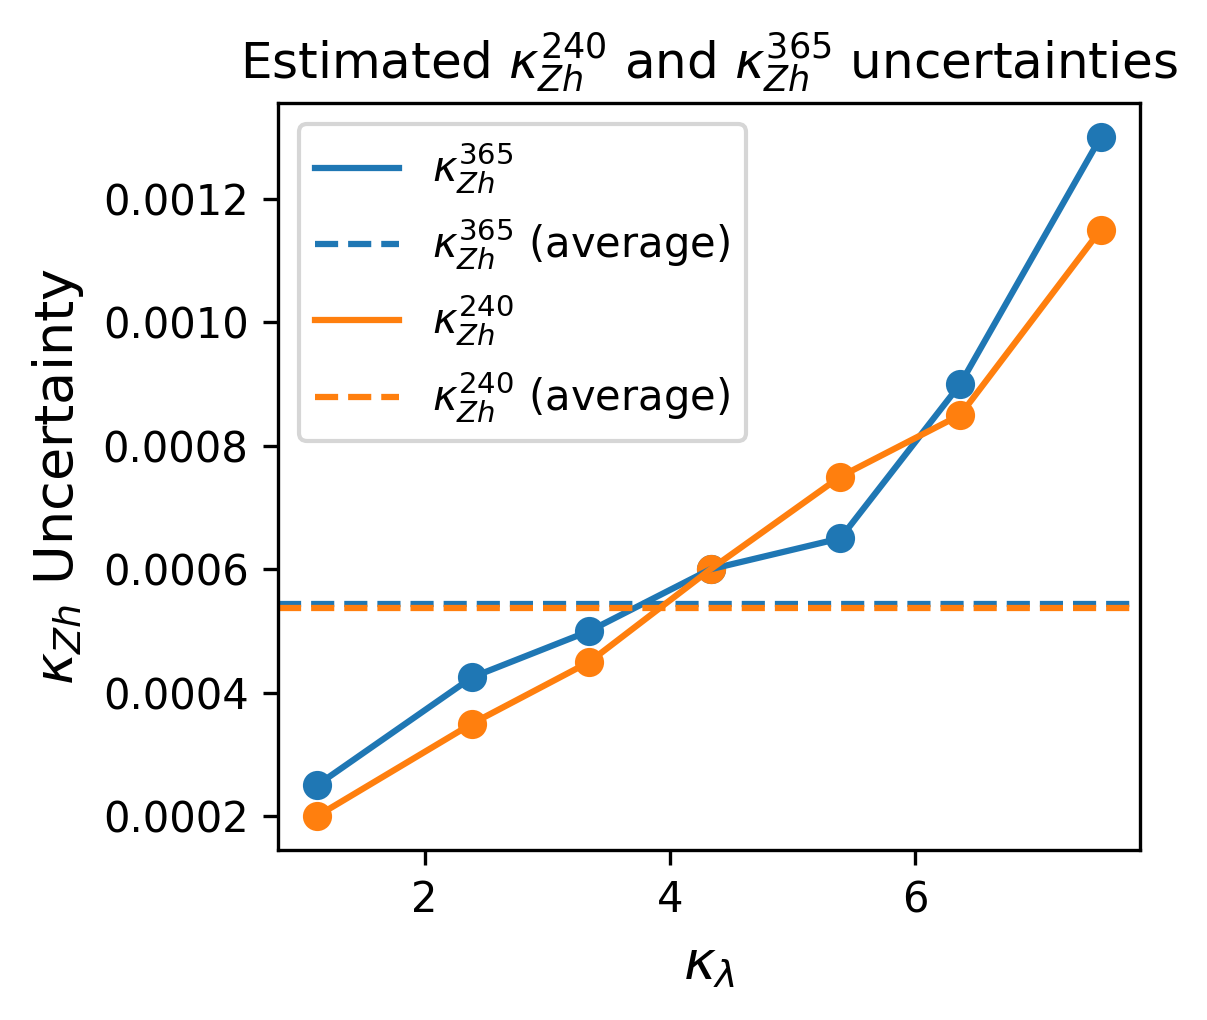

In [ ]:
fig, ax = plt.subplots(figsize=(4.0, 3.5), dpi=300)
curves = [0.5*np.array(err_xs), 0.5*np.array(err_ys)]
labels = [r"$\kappa_{Zh}^{365}$", r"$\kappa_{Zh}^{240}$"]
colors = ["tab:blue", "tab:orange",]

mean_uncertainties_kappa = [np.mean(curve[1:5]) for curve in curves]

klam = [ plot_points_with_WFR[i][2] for i in range(len(err_xs)) ]
print(f"klam = {klam}")
for curve, label, color, mean in zip(curves, labels, colors, mean_uncertainties_kappa):
    plt.plot(klam, curve, label=label, color=color)
    plt.scatter(klam, curve, color=color)

    plt.axhline(y=mean, linestyle='--', linewidth=1.5, color=color, label=label+" (average)")
    
plt.xlabel(r"$\kappa_\lambda$", fontsize=13)
plt.title(r"Estimated $\kappa_{Zh}^{240}$ and $\kappa_{Zh}^{365}$ uncertainties")
plt.ylabel(r"$\kappa_{Zh}$ Uncertainty", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_k_ZH_240_365_uncertainties.pdf")

print(f"Mean k_Zh uncertainties: 240: {mean_uncertainties_kappa[1]}, 365: {mean_uncertainties_kappa[0]}")
kappas_Zh_365 = [ (lst[0]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_365 = {kappas_Zh_365}")
kappas_Zh_240 = [ (lst[1]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_240 = {kappas_Zh_240}")
kappas_Zh = [ kappas_Zh_365[1:5], kappas_Zh_240[1:5]]

mean_kappas_Zh = [np.mean(ks[1:5]) for ks in kappas_Zh]
print(f"mean_kappas_Zh = {mean_kappas_Zh}")
mean_uncertainties_sigma = [2*kappa*mean for kappa, mean in zip(mean_kappas_Zh, mean_uncertainties_kappa)]
print(f"Mean sigma_Zh uncertainties: 240: {mean_uncertainties_sigma[1]}, 365: {mean_uncertainties_sigma[0]}")

Processing data file: data/IDM/allIDMpoints_2025-01-14


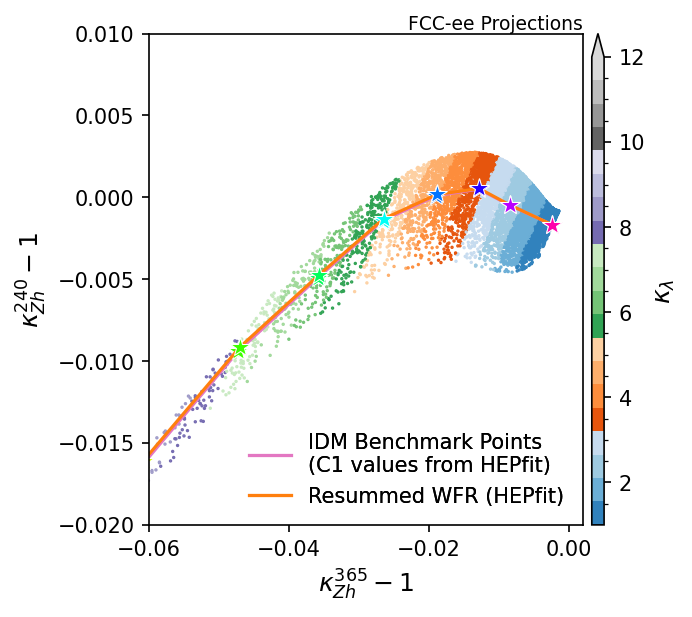

In [ ]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )
legend_locs = [None, 'lower right',]
legend_fontsizes = [10.0, 10.0,]
plot_curves (
    ax,
    curves_uncertainty_estimation[:2], 
    k_ZH_240_365_predictions_file_names[:2], 
    data_sets[:2], 
    legend_locs[:2], 
    legend_cols[:2], 
    legend_fontsizes[:2],
    markers[:2], 
    color_lines[:2], 
    label_lines[:2], 
    markersizes[:2],
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves_zoom_only_hepfit.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


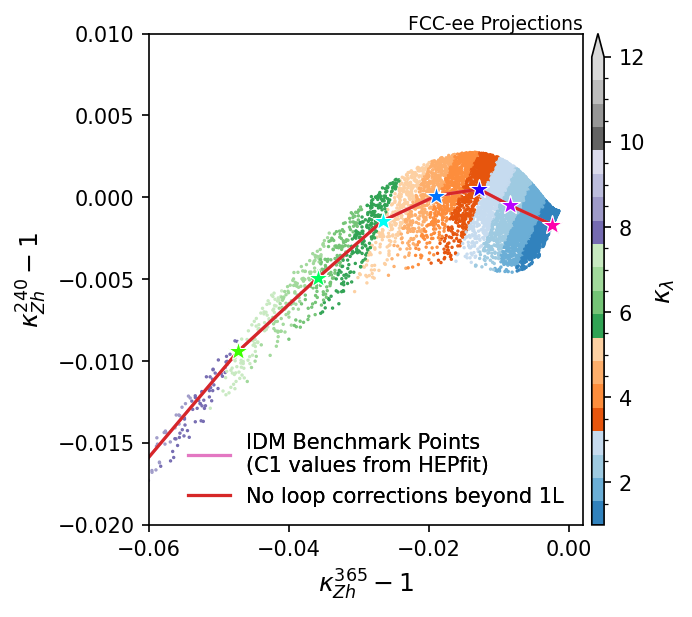

In [ ]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_Z2SSM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )
legend_locs = [None, 'lower right',]
legend_fontsizes = [10.0, 10.0,]
curves_uncertainty_estimation = ["IDM", "LoopHd6NoSubleading",]
color_lines = ["tab:pink", "tab:red",]

results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Z2SSM_fits_energy_dependence/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading.txt",
]
label_lines = [
    r'IDM Benchmark Points'+'\n'+'(C1 values from HEPfit)',
    r'No loop corrections beyond 1L',
]
plot_curves (
    ax,
    curves_uncertainty_estimation[:2], 
    k_ZH_240_365_predictions_file_names[:2], 
    data_sets[:2], 
    legend_locs[:2], 
    legend_cols[:2], 
    legend_fontsizes[:2],
    markers[:2], 
    color_lines[:2], 
    label_lines[:2], 
    markersizes[:2],
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves_zoom_only_noresum.pdf")